# Diamond Creek ETF Arbitrage — Backtest v8

**v8:** Keeps the same v7 engine/data/costs, and adds a new weighting method that combines **backtest PnL/Gross** with **screener net decay signal** (`data/etf_screened_today.csv`), then applies a **shares-available capacity cap** so short ETF targets do not exceed a configurable fraction of available lendable shares.

**Dynamic target gross multiple:** **`V7_TARGET_LEV_START` → `V7_TARGET_LEV_END`** (default **4.5× → 5.0×** NAV) as a function of how many **post-start** candidate pairs have **non-trivial gross** on the book.

**Later cells:** After the equal-weight run, save NAVs + build **v8 combined weights**, then re-backtest with **`v8_pnl_decay_shares_weights.csv`**. Final section adds a historical **shares-available** analysis from `data/runs/*/etf_screened_today.csv`.


## Setup


In [112]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, requests, time, ftplib, io, os
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

TRADING_DAYS = 252
norm_sym = lambda x: str(x).strip().upper().replace(".", "-")
print("Imports OK")


Imports OK


## Configuration


In [113]:
CFG = {
    "capital_usd":          10_000_000,
    "start_date":           "2024-12-14",
    "slippage_bps":         5,
    "ibkr_comm_per_share":  0.005,
    "ibkr_comm_min":        1.00,
    "ibkr_comm_max_pct":    0.005,
    "fallback_borrow_rate": 0.02,
    "margin_debit_spreads": [
        (100_000,      0.015),
        (1_000_000,    0.010),
        (50_000_000,   0.0075),
        (float("inf"), 0.005),
    ],
    "credit_threshold":     10_000,
    "credit_spread":        -0.005,
    "skip_ftp":             False,
    "dead_band_pct":        0.02,
    "gross_dead_band_pct":  0.05,       # full position resize if portfolio gross drifts > 5% from target
    "weight_power":         2,          # exponent applied to PnL/Gross ratios before normalising weights
    "mix_decay_weight":     0.45,       # blend: 0=PnL/Gross only, 1=decay-score only
    "decay_weight_power":   1.25,       # exponent on positive decay signal
    "position_concentration_power": 1.35, # >1 tilts more weight to biggest names
    "short_avail_use_pct":  0.25,       # softer cap: can target up to 25% of reported shares_available
    "max_pair_weight_cap":  0.20,       # hard max portfolio weight per pair after capacity logic
    "missing_shares_cap":   0.03,       # softer fallback cap when shares_available is missing
    "cap_ramp_rebals":      3,          # raise cap-constrained names over next 3 rebalances
}

LEVERAGE_RUNS = [4.5]

V7_TARGET_LEV_START = 4.5   # incumbent day-0 sizing; floor for target multiple
V7_TARGET_LEV_END = 5.0     # target multiple once all post-start pairs are on book

print(f"Capital: ${CFG['capital_usd']:,}  |  Start: {CFG['start_date']}")
print(f"Leverage: {LEVERAGE_RUNS}  |  v8 target gross multiple: {V7_TARGET_LEV_START}x → {V7_TARGET_LEV_END}x")
print("Weekly dead-band hedge  |  0% beta target  |  v8 combined weights (PnL/Gross + decay + shares cap)")


Capital: $10,000,000  |  Start: 2024-12-14
Leverage: [4.5]  |  v8 target gross multiple: 4.5x → 5.0x
Weekly dead-band hedge  |  0% beta target  |  v8 combined weights (PnL/Gross + decay + shares cap)


## PM margin — Diamond Creek sample book

Long/short equity book (~70 US names, mainly large caps and ETFs). **Source:** `data/backtest/PM Report Diamond Creek 20260326 CV.xlsx` → *Top Level Summary*.

PM notes (narrative): regulatory-style requirement lands near **$6.5MM**; **discretionary** add-on tied to crypto proxies (BITU, BITX, ETHA, ETHT, ETHU, IBIT, SOEZ); **concentration** add-on on largest names (e.g. NVDA, TSLA); small **liquidity** add-on (SOEZ). **PM/GMV** in the file is *Effective margin requirement ÷ GMV* (~17%).

The next cell loads the spreadsheet and estimates **margin excess** if gross exposure were raised to **4.5× equity** (same equity, higher GMV), by applying the file’s **MR/GMV** ratio to the new gross (equivalent to scaling today’s effective margin **linearly with GMV** when the report is internally consistent).


In [114]:
PM_XLSX = Path("data/backtest/PM Report Diamond Creek 20260326 CV.xlsx")
TARGET_GROSS_LEV = 4.5  # gross market value / equity


def _pm_top_level_snapshot(path: Path) -> dict[str, float]:
    """Parse key fields from 'Top Level Summary' (label in col 0, current in col 1)."""
    tl = pd.read_excel(path, sheet_name="Top Level Summary", header=None)
    labels = tl[0].astype(str).str.strip()

    def row_val(label: str) -> float:
        m = labels == label
        if not m.any():
            raise KeyError(f"missing row {label!r} in Top Level Summary")
        v = tl.loc[m.idxmax(), 1]
        return float(v)

    equity = row_val("Equity")
    eff_mr = row_val("Effective Margin Requirement")
    margin_xs = row_val("Margin Excess/Deficit")
    lmv = row_val("Long Market Value")
    smv = row_val("Short Market Value")
    gmv = row_val("Gross Market Value")
    try:
        pm_over_gmv = row_val("Effective Requirement / GMV")
    except KeyError:
        pm_over_gmv = eff_mr / gmv if gmv else float("nan")

    gross_lev = gmv / equity if equity else float("nan")
    return {
        "equity": equity,
        "effective_margin_req": eff_mr,
        "margin_excess": margin_xs,
        "lmv": lmv,
        "smv": smv,
        "gmv": gmv,
        "pm_over_gmv": pm_over_gmv,
        "gross_leverage_x": gross_lev,
    }


sn = _pm_top_level_snapshot(PM_XLSX)
eq = sn["equity"]
gmv0 = sn["gmv"]
mr0 = sn["effective_margin_req"]
r = sn["pm_over_gmv"]

gmv_tgt = TARGET_GROSS_LEV * eq
# Constant MR/GMV ratio (same mix in % of gross). Equivalent to scaling today's $ requirement
# linearly with GMV when Effective MR = (MR/GMV) × GMV in the report.
mr_stressed = r * gmv_tgt
xs_stressed = eq - mr_stressed
mr_linear_check = mr0 * (gmv_tgt / gmv0) if gmv0 else float("nan")

print("--- Diamond Creek PM snapshot (from xlsx) ---")
print(f"Equity:                 ${eq:>17,.0f}")
print(f"LMV / SMV:              ${sn['lmv']:>17,.0f}  /  ${sn['smv']:>17,.0f}")
print(f"GMV:                    ${gmv0:>17,.0f}  |  implied gross lev: {sn['gross_leverage_x']:.2f}x")
print(f"Effective margin req:   ${mr0:>17,.0f}  |  MR/GMV: {r * 100:.2f}%")
print(f"Margin excess (report): ${sn['margin_excess']:>17,.0f}")
print()
print(f"--- Stress: {TARGET_GROSS_LEV:.1f}x gross on same equity ---")
print(f"Target GMV ({TARGET_GROSS_LEV:.1f} × equity): ${gmv_tgt:>17,.0f}")
print()
print("Implied requirement (constant MR/GMV × target GMV):")
print(f"  Margin need:            ${mr_stressed:>17,.0f}")
print(f"  Margin excess:          ${xs_stressed:>17,.0f}  ({100 * xs_stressed / eq:.2f}% of equity)")
print(f"  vs reported excess:     ${sn['margin_excess']:>17,.0f}  → buffer vs today ${sn['margin_excess'] - xs_stressed:,.0f}")
if gmv0 and abs(mr_linear_check - mr_stressed) < 1.0:
    print()
    print("(Linear GMV scaling from today's $ margin matches this when MR/GMV is consistent with the file.)")


--- Diamond Creek PM snapshot (from xlsx) ---
Equity:                 $       10,000,000
LMV / SMV:              $       25,760,703  /  $      -12,736,857
GMV:                    $       38,497,560  |  implied gross lev: 3.85x
Effective margin req:   $        6,512,593  |  MR/GMV: 16.92%
Margin excess (report): $        3,487,407

--- Stress: 4.5x gross on same equity ---
Target GMV (4.5 × equity): $       45,000,000

Implied requirement (constant MR/GMV × target GMV):
  Margin need:            $        7,612,604
  Margin excess:          $        2,387,396  (23.87% of equity)
  vs reported excess:     $        3,487,407  → buffer vs today $1,100,011

(Linear GMV scaling from today's $ margin matches this when MR/GMV is consistent with the file.)


## Universe — v7 (same hardcoded list as v6 from `DC_Universe_Map_Filtered.xlsx`)



In [115]:
# Hardcoded from DC_Universe_Map_Filtered.xlsx (sheet "Universe Map") — all ETF slots, |β| rounded to 3dp.
CANDIDATES = [
    ("SMU", "SMR", 1.986),   ("SMUP", "SMR", 2.058),  ("QBTX", "QBTS", 1.993),
    ("BMNU", "BMNR", 1.944), ("BMNG", "BMNR", 1.993), ("ASTX", "ASTS", 1.990),
    ("CRWG", "CRWV", 1.997), ("CWVX", "CRWV", 1.990), ("WULX", "WULF", 1.997),
    ("NEBX", "NBIS", 1.999), ("NBIL", "NBIS", 1.998), ("NBIG", "NBIS", 2.009),
    ("SMCL", "SMCI", 1.990), ("CRCA", "CRCL", 1.978), ("CRCG", "CRCL", 1.990),
    ("LABX", "ALAB", 1.994), ("BEX", "BE", 1.977),    ("CLSX", "CLSK", 1.999),
    ("GLXU", "GLXY", 2.012), ("XXRP", "XRPZ", 2.020), ("XRPT", "XRPZ", 2.018),
    ("ETHU", "ETHA", 2.001), ("ETHT", "ETHA", 1.991), ("ETU", "ETHA", 1.990),
    ("CRDU", "CRDO", 1.988), ("FIGG", "FIG", 1.996),  ("SOLT", "SOEZ", 2.014),
    ("CONL", "COIN", 1.987), ("APPX", "APP", 1.984),  ("UUUG", "UUUU", 1.995),
    ("SOXL", "SOXX", 2.960), ("ROBN", "HOOD", 2.012), ("HOOG", "HOOD", 2.007),
    ("LITX", "LITE", 1.980), ("INTW", "INTC", 1.988), ("UPSX", "UPST", 1.989),
    ("CSEX", "CLS", 1.998),  ("MUU", "MU", 1.994),    ("MULL", "MU", 1.997),
    ("ARCX", "ACHR", 1.989), ("SATG", "SATS", 2.010), ("VRTL", "VRT", 1.982),
    ("GDXU", "GDX", 3.043),  ("NUGT", "GDX", 1.981),  ("TEMT", "TEM", 1.985),
    ("RDTL", "RDDT", 1.982), ("RBLU", "RBLX", 2.019), ("AMDL", "AMD", 1.997),
    ("AMUU", "AMD", 2.008),  ("AMDG", "AMD", 2.003),  ("TSLL", "TSLA", 1.993),
    ("TSLT", "TSLA", 1.993), ("TSLR", "TSLA", 1.999), ("TSLG", "TSLA", 1.991),
    ("BITX", "IBIT", 2.005), ("BITU", "IBIT", 1.992), ("BTCL", "IBIT", 2.007),
    ("YINN", "FXI", 2.974),  ("MVLL", "MRVL", 1.992), ("URAA", "URA", 1.933),
    ("SNOU", "SNOW", 2.024), ("BULG", "BULL", 1.985), ("PLTU", "PLTR", 1.992),
    ("PTIR", "PLTR", 1.997), ("PLTG", "PLTR", 1.996), ("BABX", "BABA", 2.006),
    ("NVDL", "NVDA", 1.988), ("NVDU", "NVDA", 1.986), ("NVDX", "NVDA", 1.997),
    ("NVDG", "NVDA", 1.969), ("LRCU", "LRCX", 2.045), ("ARMG", "ARM", 1.997),
    ("TSMU", "TSM", 1.990),  ("TSMG", "TSM", 1.979),  ("GEVX", "GEV", 1.993),
    ("KTUP", "KTOS", 2.026), ("AVL", "AVGO", 1.987),  ("AVGG", "AVGO", 1.999),
    ("AVGU", "AVGO", 1.992), ("UBRL", "UBER", 1.995), ("CRMG", "CRM", 1.984),
    ("UNHG", "UNH", 1.996),  ("MEXX", "EWW", 2.958),  ("JNUG", "GDXJ", 1.974),
    ("NFLU", "NFLX", 1.990), ("CWEB", "KWEB", 1.987), ("CEGX", "CEG", 1.979),
    ("GGLL", "GOOGL", 1.992),("GOOX", "GOOGL", 1.984),("KORU", "EWY", 2.931),
    ("TERG", "TER", 1.996),  ("DLLL", "DELL", 1.986), ("METU", "META", 1.999),
    ("FBL", "META", 1.997),  ("AMZU", "AMZN", 1.987), ("AMZZ", "AMZN", 1.992),
    ("PALU", "PANW", 2.006), ("ASMG", "ASML", 1.984), ("WDCX", "WDC", 2.055),
    ("CRWL", "CRWD", 1.997), ("ELIL", "LLY", 1.991),  ("PYPG", "PYPL", 1.995),
    ("BOEU", "BA", 1.987),   ("MSFU", "MSFT", 1.991), ("MSFL", "MSFT", 1.992),
    ("MSFX", "MSFT", 2.007), ("CHAU", "ASHR", 1.967), ("NOWL", "NOW", 1.996),
    ("ERX", "XLE", 1.988),   ("GUSH", "XOP", 2.011),  ("SHPU", "SHOP", 2.012),
    ("XOMX", "XOM", 1.969),  ("ORCU", "ORCL", 2.006), ("ADBG", "ADBE", 1.992),
    ("AAPU", "AAPL", 1.984), ("AAPB", "AAPL", 1.991), ("AAPX", "AAPL", 1.995),
    ("TARK", "ARKK", 1.978), ("LABU", "XBI", 2.988),  ("CSCL", "CSCO", 2.027),
    ("LMTL", "LMT", 1.984),  ("COTG", "COST", 1.987),
]

BASE_CANDIDATE_KEYS = {(e, u) for e, u, _ in CANDIDATES}

# Add all remaining screened pairs not already in the base map.
screen_paths = [Path("../data/etf_screened_today.csv"), Path("data/etf_screened_today.csv")]
_screen_path = next((p for p in screen_paths if p.exists()), None)
_added = 0
if _screen_path is not None:
    _sc = pd.read_csv(_screen_path)
    _sc.columns = [str(c).strip() for c in _sc.columns]
    req = {"ETF", "Underlying", "Beta"}
    if req.issubset(_sc.columns):
        _sc["ETF"] = _sc["ETF"].astype(str).str.upper().str.strip()
        _sc["Underlying"] = _sc["Underlying"].astype(str).str.upper().str.strip()
        _sc["Beta"] = pd.to_numeric(_sc["Beta"], errors="coerce")

        for r in _sc.itertuples(index=False):
            e = r.ETF
            u = r.Underlying
            b = float(r.Beta) if pd.notna(r.Beta) else np.nan
            if not e or not u or not np.isfinite(b):
                continue
            key = (e, u)
            if key in BASE_CANDIDATE_KEYS:
                continue
            CANDIDATES.append((e, u, round(abs(b), 3)))
            BASE_CANDIDATE_KEYS.add(key)
            _added += 1

EXTRA_ETFS = {e for e, u, _ in CANDIDATES if (e, u) not in {(x, y) for x, y, _ in [
    ("SMU", "SMR", 1),   ("SMUP", "SMR", 1),  ("QBTX", "QBTS", 1),
    ("BMNU", "BMNR", 1), ("BMNG", "BMNR", 1), ("ASTX", "ASTS", 1),
    ("CRWG", "CRWV", 1), ("CWVX", "CRWV", 1), ("WULX", "WULF", 1),
    ("NEBX", "NBIS", 1), ("NBIL", "NBIS", 1), ("NBIG", "NBIS", 1),
    ("SMCL", "SMCI", 1), ("CRCA", "CRCL", 1), ("CRCG", "CRCL", 1),
    ("LABX", "ALAB", 1), ("BEX", "BE", 1),    ("CLSX", "CLSK", 1),
    ("GLXU", "GLXY", 1), ("XXRP", "XRPZ", 1), ("XRPT", "XRPZ", 1),
    ("ETHU", "ETHA", 1), ("ETHT", "ETHA", 1), ("ETU", "ETHA", 1),
    ("CRDU", "CRDO", 1), ("FIGG", "FIG", 1),  ("SOLT", "SOEZ", 1),
    ("CONL", "COIN", 1), ("APPX", "APP", 1),  ("UUUG", "UUUU", 1),
    ("SOXL", "SOXX", 1), ("ROBN", "HOOD", 1), ("HOOG", "HOOD", 1),
    ("LITX", "LITE", 1), ("INTW", "INTC", 1), ("UPSX", "UPST", 1),
    ("CSEX", "CLS", 1),  ("MUU", "MU", 1),    ("MULL", "MU", 1),
    ("ARCX", "ACHR", 1), ("SATG", "SATS", 1), ("VRTL", "VRT", 1),
    ("GDXU", "GDX", 1),  ("NUGT", "GDX", 1),  ("TEMT", "TEM", 1),
    ("RDTL", "RDDT", 1), ("RBLU", "RBLX", 1), ("AMDL", "AMD", 1),
    ("AMUU", "AMD", 1),  ("AMDG", "AMD", 1),  ("TSLL", "TSLA", 1),
    ("TSLT", "TSLA", 1), ("TSLR", "TSLA", 1), ("TSLG", "TSLA", 1),
    ("BITX", "IBIT", 1), ("BITU", "IBIT", 1), ("BTCL", "IBIT", 1),
    ("YINN", "FXI", 1),  ("MVLL", "MRVL", 1), ("URAA", "URA", 1),
    ("SNOU", "SNOW", 1), ("BULG", "BULL", 1), ("PLTU", "PLTR", 1),
    ("PTIR", "PLTR", 1), ("PLTG", "PLTR", 1), ("BABX", "BABA", 1),
    ("NVDL", "NVDA", 1), ("NVDU", "NVDA", 1), ("NVDX", "NVDA", 1),
    ("NVDG", "NVDA", 1), ("LRCU", "LRCX", 1), ("ARMG", "ARM", 1),
    ("TSMU", "TSM", 1),  ("TSMG", "TSM", 1),  ("GEVX", "GEV", 1),
    ("KTUP", "KTOS", 1), ("AVL", "AVGO", 1),  ("AVGG", "AVGO", 1),
    ("AVGU", "AVGO", 1), ("UBRL", "UBER", 1), ("CRMG", "CRM", 1),
    ("UNHG", "UNH", 1),  ("MEXX", "EWW", 1),  ("JNUG", "GDXJ", 1),
    ("NFLU", "NFLX", 1), ("CWEB", "KWEB", 1), ("CEGX", "CEG", 1),
    ("GGLL", "GOOGL", 1),("GOOX", "GOOGL", 1),("KORU", "EWY", 1),
    ("TERG", "TER", 1),  ("DLLL", "DELL", 1), ("METU", "META", 1),
    ("FBL", "META", 1),  ("AMZU", "AMZN", 1), ("AMZZ", "AMZN", 1),
    ("PALU", "PANW", 1), ("ASMG", "ASML", 1), ("WDCX", "WDC", 1),
    ("CRWL", "CRWD", 1), ("ELIL", "LLY", 1),  ("PYPG", "PYPL", 1),
    ("BOEU", "BA", 1),   ("MSFU", "MSFT", 1), ("MSFL", "MSFT", 1),
    ("MSFX", "MSFT", 1), ("CHAU", "ASHR", 1), ("NOWL", "NOW", 1),
    ("ERX", "XLE", 1),   ("GUSH", "XOP", 1),  ("SHPU", "SHOP", 1),
    ("XOMX", "XOM", 1),  ("ORCU", "ORCL", 1), ("ADBG", "ADBE", 1),
    ("AAPU", "AAPL", 1), ("AAPB", "AAPL", 1), ("AAPX", "AAPL", 1),
    ("TARK", "ARKK", 1), ("LABU", "XBI", 1),  ("CSCL", "CSCO", 1),
    ("LMTL", "LMT", 1),  ("COTG", "COST", 1),
]}}

# Rebuild additions with explicit Beta filter: include only screened ETFs with Beta > 1.5.
_base_keys = {(e, u) for e, u, _ in CANDIDATES if e not in EXTRA_ETFS}
base_candidates = [t for t in CANDIDATES if (t[0], t[1]) in _base_keys]

extra_candidates = []
EXTRA_ETFS = set()
if _screen_path is not None and req.issubset(_sc.columns):
    for r in _sc.itertuples(index=False):
        e = str(r.ETF).upper().strip()
        u = str(r.Underlying).upper().strip()
        b = float(r.Beta) if pd.notna(r.Beta) else np.nan
        if not e or not u or not np.isfinite(b):
            continue
        if b <= 1.5:
            continue
        key = (e, u)
        if key in _base_keys:
            continue
        extra_candidates.append((e, u, round(b, 3)))
        EXTRA_ETFS.add(e)

# Deduplicate while preserving order.
_seen = set()
CANDIDATES = []
for e, u, b in base_candidates + extra_candidates:
    k = (e, u)
    if k in _seen:
        continue
    _seen.add(k)
    CANDIDATES.append((e, u, b))

print(f"Total candidate pairs: {len(CANDIDATES)} | Added from screener (positive Beta>1.5): {len(extra_candidates)}")
print(f"Additional ETF names (capacity-sized only): {len(EXTRA_ETFS)}")


Total candidate pairs: 250 | Added from screener (positive Beta>1.5): 128
Additional ETF names (capacity-sized only): 128


## Data — Borrow Rates, Prices, Pair Selection


In [117]:
# ---- Borrow rates (FTP or flat fallback) ----
all_etf_syms = [e for e, _, _ in CANDIDATES]
BORROW_CACHE = Path("data/borrow_cache.csv")

if CFG.get("skip_ftp"):
    print(f"[FTP] Skipped — flat {CFG['fallback_borrow_rate']:.2%}")
    BORROW_MAP = {e: CFG["fallback_borrow_rate"] for e in all_etf_syms}
else:
    BORROW_MAP = {}
    raw_df = None
    for attempt in range(1, 4):
        try:
            print(f"[FTP] Connecting (attempt {attempt}/3)...")
            ftp = ftplib.FTP(timeout=30); ftp.connect("ftp2.interactivebrokers.com", 21)
            ftp.login(user="shortstock", passwd=""); ftp.set_pasv(True)
            buf = io.BytesIO(); ftp.retrbinary("RETR usa.txt", buf.write)
            try: ftp.quit()
            except: pass
            text = buf.getvalue().decode("utf-8", errors="ignore")
            lines = [ln for ln in text.splitlines() if ln.strip()]
            hdr_idx = next(i for i, ln in enumerate(lines) if ln.startswith("#SYM|"))
            hdr = [c.strip().lstrip("#").lower() for c in lines[hdr_idx].split("|")]
            data_lines = lines[hdr_idx + 1:]
            raw_df = pd.read_csv(io.StringIO("\n".join(data_lines)), sep="|", header=None, engine="python")
            raw_df = raw_df.iloc[:, :min(len(hdr), raw_df.shape[1])]
            raw_df.columns = hdr[:raw_df.shape[1]]
            print(f"[FTP] Parsed {len(raw_df)} rows")
            BORROW_CACHE.parent.mkdir(parents=True, exist_ok=True)
            raw_df.to_csv(BORROW_CACHE, index=False)
            break
        except Exception as e:
            if attempt < 3: time.sleep(2**attempt)
            else:
                print(f"[FTP] Failed: {e}")
                if BORROW_CACHE.exists():
                    raw_df = pd.read_csv(BORROW_CACHE)
                    print(f"[FTP] Loaded cache ({len(raw_df)} rows)")
    if raw_df is not None:
        def _pr(x):
            try: return float(str(x).replace("%","").strip()) / 100
            except: return np.nan
        raw_df["sym"] = raw_df["sym"].astype(str).str.upper().str.strip()
        raw_df["fee"] = raw_df["feerate"].map(_pr).clip(lower=0)
        agg = raw_df.groupby("sym")["fee"].max()
        found = missing = 0
        for e in all_etf_syms:
            if e in agg.index and pd.notna(agg[e]):
                BORROW_MAP[e] = float(agg[e]); found += 1
            else:
                BORROW_MAP[e] = CFG["fallback_borrow_rate"]; missing += 1
        print(f"[FTP] {found} from FTP, {missing} fallback")
    else:
        BORROW_MAP = {e: CFG["fallback_borrow_rate"] for e in all_etf_syms}


[FTP] Connecting (attempt 1/3)...
[FTP] Parsed 18907 rows
[FTP] 224 from FTP, 26 fallback


In [118]:
# ---- Total-return prices ----
import yfinance as yf

# Manual split overrides for outlier tickers/dates (applied in raw-close path).
# Example: reverse split 1-for-10 => factor 0.1 on split date.
MANUAL_SPLIT_OVERRIDES = {
    "SMUP": {
        # For this feed representation, 10.0 neutralizes the reverse-split discontinuity.
        "2026-01-26": 10.0,
    },
}

def download_total_return(ticker, period="max"):
    try:
        tk = yf.Ticker(ticker)
        df = tk.history(period=period, auto_adjust=False, actions=True)
        if df.empty or "Close" not in df.columns:
            return None
        df = df.sort_index()

        tkr = str(ticker).upper()
        manual_splits = globals().get("MANUAL_SPLIT_OVERRIDES", {})
        force_raw_path = tkr in manual_splits

        # Prefer Yahoo adjusted close unless we explicitly need manual split overrides.
        if (not force_raw_path) and ("Adj Close" in df.columns) and (df["Adj Close"].notna().sum() > 20):
            tr = df["Adj Close"].astype(float)
            tr.index = tr.index.tz_localize(None)
            return tr.replace([np.inf, -np.inf], np.nan).dropna()

        close = df["Close"].astype(float)
        divs = (
            df["Dividends"].fillna(0).astype(float)
            if "Dividends" in df.columns
            else pd.Series(0.0, index=close.index)
        )
        splits = (
            df["Stock Splits"].replace(0, 1).fillna(1).astype(float)
            if "Stock Splits" in df.columns
            else pd.Series(1.0, index=close.index)
        )

        # Manual split overrides for outlier names/dates.
        # Apply on exact date, or nearest next trading day within 3 calendar days.
        if tkr in manual_splits:
            applied = []
            for ds, factor in manual_splits[tkr].items():
                ts = pd.Timestamp(ds)
                apply_ts = None
                if ts in splits.index:
                    apply_ts = ts
                else:
                    nxt = splits.index[splits.index >= ts]
                    if len(nxt) > 0 and (nxt[0] - ts).days <= 3:
                        apply_ts = nxt[0]

                if apply_ts is None:
                    print(f"[split-override] {tkr} {ts.date()} not applied (date not found)")
                    continue

                f = float(factor)
                old_factor = float(splits.loc[apply_ts])

                # Back-adjust all history before split day to post-split basis.
                # Here, `factor` is interpreted as the pre-split back-adjust multiplier.
                close.loc[close.index < apply_ts] = close.loc[close.index < apply_ts] * f
                divs.loc[divs.index < apply_ts] = divs.loc[divs.index < apply_ts] * f

                # Neutralize split jump on event day because history is already back-adjusted.
                splits.loc[apply_ts] = 1.0

                applied.append((ts, apply_ts, old_factor, f))

            if applied:
                for ts, apply_ts, old_factor, f in applied:
                    print(
                        f"[split-override] {tkr} requested {ts.date()} applied {apply_ts.date()} "
                        f"back-adjust x{f:g}, split-factor {old_factor:g} -> 1 (event-day neutralized)"
                    )
            else:
                print(f"[split-override] {tkr} had no applied overrides")

        # Daily total-return factor with split and dividend handling.
        gross = ((close * splits) + divs) / close.shift(1)
        gross = gross.replace([np.inf, -np.inf], np.nan).fillna(1.0)
        tr = close.iloc[0] * gross.cumprod()
        tr.index = tr.index.tz_localize(None)
        return tr.replace([np.inf, -np.inf], np.nan).dropna()
    except:
        return None

ALL_TICKERS = sorted(set(e for e, _, _ in CANDIDATES) | set(u for _, u, _ in CANDIDATES) | {"SPY"})
t0 = time.time()
print(f"Downloading {len(ALL_TICKERS)} tickers...")
PRICES = {}
with ThreadPoolExecutor(max_workers=8) as ex:
    futs = {ex.submit(download_total_return, t): t for t in ALL_TICKERS}
    done = 0
    for f in as_completed(futs):
        done += 1
        t = futs[f]
        s = f.result()
        if s is not None and len(s) > 20:
            PRICES[t] = s
        if done % 20 == 0:
            print(f"  {done}/{len(ALL_TICKERS)} [{time.time()-t0:.0f}s]")
print(f"Got {len(PRICES)}/{len(ALL_TICKERS)} [{time.time()-t0:.1f}s]")
if globals().get("MANUAL_SPLIT_OVERRIDES"):
    print("Manual split overrides active:")
    for _t, _m in MANUAL_SPLIT_OVERRIDES.items():
        for _d, _f in _m.items():
            print(f"  {_t} {_d} factor={_f}")

# ---- Manual bad-print repairs (targeted) ----
# Modes:
# - "interpolate": one-day midpoint interpolation from neighbors
# - {"mode": "interpolate_window", "dates": [...]}: replace listed dates by
#   linear interpolation anchored by nearest clean observations outside the window.
# - {"mode": "beta_from_underlying", "underlying": "SMR", "beta": 2.058}:
#   reprice ETF on that date from underlying return and beta.
# Keep empty by default; leave hook in place for non-split bad ticks if ever needed.
MANUAL_TR_PRICE_FIXES = {}


def _apply_manual_price_fixes(prices_map, fixes):
    applied = []

    for ticker, dmap in fixes.items():
        s = prices_map.get(ticker)
        if s is None or s.empty:
            continue
        s = s.sort_index().copy()

        # First handle explicit windows.
        for _, spec in dmap.items():
            if not isinstance(spec, dict) or spec.get("mode") != "interpolate_window":
                continue

            dates = [pd.Timestamp(x) for x in spec.get("dates", [])]
            dates = sorted([d for d in dates if d in s.index])
            if not dates:
                continue

            left_idx = s.index[s.index < dates[0]]
            right_idx = s.index[s.index > dates[-1]]
            if left_idx.empty or right_idx.empty:
                continue

            left_t = left_idx[-1]
            right_t = right_idx[0]
            y0 = float(s.loc[left_t])
            y1 = float(s.loc[right_t])
            x0 = float(left_t.value)
            x1 = float(right_t.value)
            if x1 <= x0:
                continue

            for ts in dates:
                old = float(s.loc[ts])
                x = float(ts.value)
                w = (x - x0) / (x1 - x0)
                new = y0 + w * (y1 - y0)
                s.loc[ts] = new
                applied.append((ticker, ts, old, float(new), "interpolate_window"))

        # Then handle single-date fixes.
        for ds, mode in dmap.items():
            ts = pd.Timestamp(ds)
            if ts not in s.index:
                continue

            # Dict mode for date-specific advanced fixes.
            if isinstance(mode, dict):
                m = mode.get("mode")
                if m == "beta_from_underlying":
                    und = str(mode.get("underlying", "")).upper()
                    beta = float(mode.get("beta", 1.0))
                    su = prices_map.get(und)
                    prev_idx = s.index[s.index < ts]
                    if su is None or su.empty or prev_idx.empty:
                        continue

                    prev_t = prev_idx[-1]
                    p_u_t = float(su.asof(ts))
                    p_u_prev = float(su.asof(prev_t))
                    p_e_prev = float(s.loc[prev_t])
                    if p_u_prev <= 0 or p_e_prev <= 0:
                        continue

                    r_u = p_u_t / p_u_prev - 1.0
                    new = max(1e-6, p_e_prev * (1.0 + beta * r_u))
                    old = float(s.loc[ts])
                    s.loc[ts] = new
                    applied.append((ticker, ts, old, float(new), f"beta_from_{und}"))
                continue

            old = float(s.loc[ts])
            prev = s[s.index < ts]
            nxt = s[s.index > ts]

            if mode == "interpolate" and not prev.empty and not nxt.empty:
                new = float((prev.iloc[-1] + nxt.iloc[0]) / 2.0)
            elif not prev.empty:
                new = float(prev.iloc[-1])
            elif not nxt.empty:
                new = float(nxt.iloc[0])
            else:
                continue

            s.loc[ts] = new
            applied.append((ticker, ts, old, new, mode))

        prices_map[ticker] = s

    if applied:
        print("Applied manual price fixes:")
        for ticker, ts, old, new, mode in applied:
            print(f"  {ticker} {ts.date()} [{mode}] {old:,.4f} -> {new:,.4f}")
    else:
        print("No manual price fixes applied.")


_apply_manual_price_fixes(PRICES, MANUAL_TR_PRICE_FIXES)

# Quick sanity check: max absolute Jan-2026 daily return.
for _sym in ["SMR", "SMUP"]:
    _s = PRICES.get(_sym)
    if _s is None or _s.empty:
        continue
    _jan = _s[(_s.index >= pd.Timestamp("2026-01-01")) & (_s.index < pd.Timestamp("2026-02-01"))]
    _r = _jan.pct_change().dropna()
    if not _r.empty:
        _d = _r.abs().idxmax()
        print(f"{_sym} largest Jan return: {_d.date()} | {_r.loc[_d]:.2%}")

# ---- Fed Funds ----
try:
    fred_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DFF"
    ff_df = pd.read_csv(fred_url)
    ff_df.columns = [str(c).strip() for c in ff_df.columns]

    # FRED schema can be either DATE or observation_date.
    date_col = "DATE" if "DATE" in ff_df.columns else ("observation_date" if "observation_date" in ff_df.columns else None)
    if date_col is None or "DFF" not in ff_df.columns:
        raise KeyError(f"Unexpected FRED columns: {list(ff_df.columns)}")

    ff_df["date"] = pd.to_datetime(ff_df[date_col], errors="coerce")
    ff_df["rate"] = pd.to_numeric(ff_df["DFF"], errors="coerce")
    ff_df = ff_df.dropna(subset=["date", "rate"]).set_index("date").sort_index()
    FED_FUNDS_DAILY = (ff_df["rate"] / 100).astype(float)
    print(f"Fed Funds: {len(FED_FUNDS_DAILY)} daily obs ({date_col})")
except Exception as e:
    print(f"FRED failed ({e}), using fallback")
    fomc = [(pd.Timestamp("2022-12-14"), 0.0433), (pd.Timestamp("2023-02-01"), 0.0458),
            (pd.Timestamp("2023-03-22"), 0.0483), (pd.Timestamp("2023-05-03"), 0.0508),
            (pd.Timestamp("2023-07-26"), 0.0533), (pd.Timestamp("2024-09-18"), 0.0483),
            (pd.Timestamp("2024-11-07"), 0.0458), (pd.Timestamp("2024-12-18"), 0.0433),
            (pd.Timestamp("2025-01-29"), 0.0433)]
    FED_FUNDS_DAILY = pd.Series({d: r for d, r in fomc}).sort_index()


  20/435 [3s]
  40/435 [4s]
  60/435 [4s]
  80/435 [4s]
  100/435 [5s]
  120/435 [6s]
  140/435 [6s]
  160/435 [10s]
  180/435 [11s]
  200/435 [13s]
  220/435 [14s]
  240/435 [15s]
  260/435 [15s]
  280/435 [16s]
  300/435 [16s]
  320/435 [17s]
  340/435 [17s]
  360/435 [18s]
  380/435 [18s]
  400/435 [18s]
  420/435 [19s]
Got 431/435 [19.5s]
Manual split overrides active:
  SMUP 2026-01-26 factor=10.0
No manual price fixes applied.
SMR largest Jan return: 2026-01-05 | 15.14%
Fed Funds: 26202 daily obs (observation_date)


In [119]:
# ---- Inception dates + full universe (post–start_date listings join when data exists) ----
start_ts = pd.Timestamp(CFG["start_date"])

INCEPTION = {}
for etf, und, bv in CANDIDATES:
    s_e = PRICES.get(etf)
    s_u = PRICES.get(und)
    if s_e is not None and s_u is not None:
        first = max(s_e.index[0], s_u.index[0])
        INCEPTION[(etf, und)] = first

UNIVERSE = [(e, u, b) for e, u, b in CANDIDATES if (e, u) in INCEPTION]
UNIVERSE.sort(key=lambda x: INCEPTION[(x[0], x[1])])

RAMP_WEEKS = 4  # weekly rebalances to scale new listings from 1/RAMP_WEEKS → full weight

n_at_start = sum(1 for e, u, b in UNIVERSE if INCEPTION[(e, u)] <= start_ts)
print(f"Pairs with overlapping price data: {len(INCEPTION)} / {len(CANDIDATES)}")
print(f"Full UNIVERSE: {len(UNIVERSE)} pairs (v7: incremental engine)")
print(f"Tradeable at {CFG['start_date']}: {n_at_start} pairs | RAMP_WEEKS={RAMP_WEEKS}")
print()
for i, (e, u, b) in enumerate(UNIVERSE, 1):
    inc = INCEPTION[(e, u)].strftime("%Y-%m-%d")
    tag = "  [post-start]" if INCEPTION[(e, u)] > start_ts else ""
    print(f"  {i:3d}  {e:5s}  {u:5s}  {b:.3f}  {inc}{tag}")


Pairs with overlapping price data: 246 / 250
Full UNIVERSE: 246 pairs (v7: incremental engine)
Tradeable at 2024-12-14: 58 pairs | RAMP_WEEKS=4

    1  ERX    XLE    1.988  2008-11-19
    2  YINN   FXI    2.974  2009-12-03
    3  SOXL   SOXX   2.960  2010-03-11
    4  NUGT   GDX    1.981  2010-12-08
    5  KORU   EWY    2.931  2013-04-10
    6  JNUG   GDXJ   1.974  2013-10-03
    7  CHAU   ASHR   1.967  2015-04-16
    8  LABU   XBI    2.988  2015-05-28
    9  GUSH   XOP    2.011  2015-05-29
   10  CWEB   KWEB   1.987  2016-11-10
   11  MEXX   EWW    2.958  2017-05-03
   12  HIBL   SPY    4.483  2019-11-07
   13  GDXU   GDX    3.043  2020-12-03
   14  TARK   ARKK   1.978  2022-05-02
   15  TSLL   TSLA   1.993  2022-08-09
   16  AAPU   AAPL   1.984  2022-08-09
   17  CONL   COIN   1.987  2022-08-10
   18  AAPB   AAPL   1.991  2022-08-10
   19  GGLL   GOOGL  1.992  2022-09-07
   20  AMZU   AMZN   1.987  2022-09-07
   21  MSFU   MSFT   1.991  2022-09-07
   22  BABX   BABA   2.006  2022-12-

## Cost Functions


In [120]:
def trade_cost(tusd, px, cfg):
    if abs(tusd) < 1 or px <= 0:
        return 0.0
    sh = abs(tusd) / px
    comm = max(cfg["ibkr_comm_min"],
               min(sh * cfg["ibkr_comm_per_share"], abs(tusd) * cfg["ibkr_comm_max_pct"]))
    return comm + abs(tusd) * cfg["slippage_bps"] / 10000

def margin_debit_interest(debit, benchmark_rate, spreads):
    if debit <= 0:
        return 0.0
    remaining, interest, prev = debit, 0.0, 0.0
    for threshold, spread in spreads:
        rate = max(0.0, benchmark_rate + spread)
        amt = min(remaining, threshold - prev)
        if amt > 0:
            interest += amt * rate / TRADING_DAYS
            remaining -= amt
        prev = threshold
        if remaining <= 0:
            break
    return interest

def short_credit_interest(short_notional, benchmark_rate, credit_spread):
    if short_notional <= 0:
        return 0.0
    rate = max(0.0, benchmark_rate + credit_spread)
    return short_notional * rate / TRADING_DAYS

def _get_fed_funds(dt):
    val = FED_FUNDS_DAILY.asof(dt)
    return 0.04 if pd.isna(val) else float(val)

print("Cost functions OK")


Cost functions OK


## Backtest Engine — v8 base engine (incremental adds, dynamic target gross)

- **Day 0:** Incumbents only, gross target **`NAV × V7_TARGET_LEV_START`** (same as a 4.5× launch book).
- **Later rebalances:** Apply **v5-style gross control**: if gross drift exceeds `gross_dead_band_pct`, run full `_apply_allocs` for all eligible pairs; otherwise beta-hedge shorts inside the dead band.
- **Post-start adds:** `_apply_one_pair` toward `tgt_gross_nav × (wcomb/Σw)` for active post-start names, with `RAMP_WEEKS` ramp-in.
- **Target gross:** `tgt_gross_nav = NAV × target_lev` with `target_lev` linear in **fraction of post-start pairs** with gross > \$1.


In [121]:
spy = PRICES.get("SPY")
tdays = spy.index[spy.index >= start_ts].sort_values()

s = pd.Series(range(len(tdays)), index=tdays)
rebal_idx = s.resample("W-FRI").last().dropna()
rebal_days = set(tdays[int(i)] for i in rebal_idx.values)

n_pairs = len(UNIVERSE)
INC_ETFS = frozenset(
    etf for etf, und, bv in UNIVERSE if INCEPTION[(etf, und)] <= start_ts
)
POST_ETFS = frozenset(
    etf for etf, und, bv in UNIVERSE if INCEPTION[(etf, und)] > start_ts
)

print(f"Trading days: {len(tdays)} | Rebalance days: {len(rebal_days)} (weekly)")
print(f"Pairs: {n_pairs} | Incumbents (≤ start): {len(INC_ETFS)} | Post-start: {len(POST_ETFS)}")
print(f"Start: {tdays[0].strftime('%Y-%m-%d')} | End: {tdays[-1].strftime('%Y-%m-%d')}")
print(
    f"v8 target gross multiple: {V7_TARGET_LEV_START}x → {V7_TARGET_LEV_END}x "
    f"as post-start pairs join (v5-style incumbent hedging + dead-band gross control)"
)

if "PAIR_WEIGHTS" not in dir():
    PAIR_WEIGHTS = {e: 1.0 / n_pairs for e, _, _ in UNIVERSE}
    print(f"Using equal weights: {1.0/n_pairs:.4%} per pair")
else:
    print(f"Using custom PAIR_WEIGHTS ({len(PAIR_WEIGHTS)} pairs, top weight: {max(PAIR_WEIGHTS.values()):.2%})")

ALL_BT = {}
ALL_PAIR_PNL = {}
ALL_PAIR_NET = {}
ALL_PAIR_GROSS = {}

for gross_lev in LEVERAGE_RUNS:
    print(f"\n{'='*60}")
    print(
        f"  v7 RUN (store key {gross_lev}x) | dynamic tgt gross {V7_TARGET_LEV_START}x–{V7_TARGET_LEV_END}x"
    )
    print(f"{'='*60}")

    cash = float(CFG["capital_usd"])
    holdings = {}
    pair_pos = {}
    pair_pnl = {}
    daily_rows = []
    tot_costs = tot_borrow = tot_margin_debit = tot_margin_credit = 0.0
    rebal_count = 0
    pair_entry_rebal: dict[tuple[str, str], int] = {}
    prev_px = {}
    cum_long_pnl = cum_short_pnl = 0.0
    pair_net_rows = []
    pair_gross_rows = []

    def _execute_trade(sym, tgt_sh, px_map):
        global cash
        cur_sh = holdings.get(sym, 0)
        delta = tgt_sh - cur_sh
        p = px_map.get(sym, 0)
        trade_usd = abs(delta * p)
        if p <= 0 or trade_usd < 1:
            return 0.0, 0.0
        cash -= delta * p
        c = trade_cost(trade_usd, p, CFG)
        cash -= c
        if abs(tgt_sh) < 1:
            holdings.pop(sym, None)
        else:
            holdings[sym] = tgt_sh
        return trade_usd, c

    def _frac_rows_for_day(today, R: int):
        rows = []
        for etf, und, bv in UNIVERSE:
            key = (etf, und)
            if INCEPTION[key] > today:
                continue
            if INCEPTION[key] <= start_ts:
                rp = 1.0
            else:
                if key not in pair_entry_rebal:
                    pair_entry_rebal[key] = R
                rp = min(1.0, (R - pair_entry_rebal[key] + 1) / float(RAMP_WEEKS))
            wb = PAIR_WEIGHTS.get(etf, 1.0 / n_pairs)
            rows.append((etf, und, bv, wb * rp))
        return rows

    def _pair_gross_usd(ek, px_map):
        pos = pair_pos.get(ek)
        if not pos:
            return 0.0
        uk = pos["und"]
        return max(pos["long_sh"], 0) * px_map.get(
            uk, 0
        ) + max(-pos["short_sh"], 0) * px_map.get(ek, 0)

    def _target_lev_for_book(px_map):
        if not POST_ETFS:
            return float(V7_TARGET_LEV_START)
        on = sum(1 for ek in POST_ETFS if _pair_gross_usd(ek, px_map) > 1.0)
        prog = on / float(len(POST_ETFS))
        return V7_TARGET_LEV_START + (V7_TARGET_LEV_END - V7_TARGET_LEV_START) * prog

    def _apply_allocs(tgt_gross: float, frac_rows, px_map: dict) -> dict:
        tw = sum(r[3] for r in frac_rows)
        tgt_shares: dict = {}
        if tw <= 0:
            return tgt_shares
        for etf, und, bv, wcomb in frac_rows:
            frac = wcomb / tw
            alloc = tgt_gross * frac
            p_u, p_e = px_map.get(und, 0), px_map.get(etf, 0)
            if p_u <= 0 or p_e <= 0:
                continue
            babs = abs(bv)
            hr = 1.0 / babs
            long_usd = alloc / (1.0 + hr)
            short_usd = alloc - long_usd
            lsh = int(round(long_usd / p_u))
            ssh = -int(round(short_usd / p_e))
            pair_pos[etf] = {"und": und, "long_sh": lsh, "short_sh": ssh}
            if etf not in pair_pnl:
                pair_pnl[etf] = {"und": und, "long": 0.0, "short": 0.0}
            tgt_shares[und] = tgt_shares.get(und, 0) + lsh
            tgt_shares[etf] = tgt_shares.get(etf, 0) + ssh
        return tgt_shares

    def _apply_one_pair(
        tgt_shares: dict, etf, und, bv, alloc_usd: float, px_map: dict
    ) -> None:
        p_u, p_e = px_map.get(und, 0), px_map.get(etf, 0)
        if p_u <= 0 or p_e <= 0 or alloc_usd <= 0:
            return
        babs = abs(bv)
        hr = 1.0 / babs
        long_usd = alloc_usd / (1.0 + hr)
        short_usd = alloc_usd - long_usd
        lsh = int(round(long_usd / p_u))
        ssh = -int(round(short_usd / p_e))
        pair_pos[etf] = {"und": und, "long_sh": lsh, "short_sh": ssh}
        if etf not in pair_pnl:
            pair_pnl[etf] = {"und": und, "long": 0.0, "short": 0.0}
        tgt_shares[und] = tgt_shares.get(und, 0) + lsh
        tgt_shares[etf] = tgt_shares.get(etf, 0) + ssh

    for di, today in enumerate(tdays):
        px = {}
        for sym, ser in PRICES.items():
            if today in ser.index:
                px[sym] = float(ser.loc[today])
            else:
                prior = ser[ser.index <= today]
                if not prior.empty:
                    px[sym] = float(prior.iloc[-1])

        daily_long_pnl = daily_short_pnl = 0.0
        if di > 0 and prev_px:
            for ek, pos in pair_pos.items():
                uk = pos["und"]
                dp_u = px.get(uk, 0) - prev_px.get(uk, 0)
                dp_e = px.get(ek, 0) - prev_px.get(ek, 0)
                l_pnl = pos["long_sh"] * dp_u if pos["long_sh"] > 0 else 0.0
                s_pnl = pos["short_sh"] * dp_e if pos["short_sh"] < 0 else 0.0
                daily_long_pnl += l_pnl
                daily_short_pnl += s_pnl
                pair_pnl[ek]["long"] += l_pnl
                pair_pnl[ek]["short"] += s_pnl
        cum_long_pnl += daily_long_pnl
        cum_short_pnl += daily_short_pnl

        mtm = sum(sh * px.get(sym, 0) for sym, sh in holdings.items())
        nav = cash + mtm

        borrow_d = 0.0
        for sym, sh in holdings.items():
            if sh < 0:
                borrow_d += (
                    abs(sh)
                    * px.get(sym, 0)
                    * BORROW_MAP.get(sym, CFG["fallback_borrow_rate"])
                    / TRADING_DAYS
                )
        cash -= borrow_d
        tot_borrow += borrow_d

        ff = _get_fed_funds(today)
        l_notional = sum(
            sh * px.get(sym, 0) for sym, sh in holdings.items() if sh > 0
        )
        s_notional = sum(
            abs(sh) * px.get(sym, 0) for sym, sh in holdings.items() if sh < 0
        )

        long_financing = max(0.0, l_notional - CFG["capital_usd"])
        margin_debit_d = margin_debit_interest(
            long_financing, ff, CFG["margin_debit_spreads"]
        )
        cash -= margin_debit_d
        tot_margin_debit += margin_debit_d

        margin_credit_d = short_credit_interest(
            s_notional, ff, CFG["credit_spread"]
        )
        cash += margin_credit_d
        tot_margin_credit += margin_credit_d

        mtm = sum(sh * px.get(sym, 0) for sym, sh in holdings.items())
        nav = cash + mtm

        trade_turnover = 0.0
        dc = 0.0
        is_rebal = (today in rebal_days) or (di == 0)

        if is_rebal:
            rebal_count += 1
            frac_rows = _frac_rows_for_day(today, rebal_count)
            db = CFG["dead_band_pct"]
            tw = sum(r[3] for r in frac_rows)
            gdb = CFG.get("gross_dead_band_pct", 0.05)

            target_lev_t = _target_lev_for_book(px)
            tgt_gross_nav = nav * target_lev_t

            actual_gross = sum(
                max(p.get("long_sh", 0), 0) * px.get(p["und"], 0)
                + max(-p.get("short_sh", 0), 0) * px.get(ek, 0)
                for ek, p in pair_pos.items()
            )
            gross_drift = (
                abs(actual_gross - tgt_gross_nav) / tgt_gross_nav
                if tgt_gross_nav > 0
                else 0
            )

            tgt_shares: dict = {}

            if di == 0:
                rows0 = [r for r in frac_rows if r[0] in INC_ETFS]
                tw0 = sum(r[3] for r in rows0)
                if tw0 <= 0:
                    raise RuntimeError("v7 day 0: no incumbent frac_rows")
                tgt0 = nav * float(V7_TARGET_LEV_START)
                tgt_shares = _apply_allocs(tgt0, rows0, px)
            else:
                if gross_drift > gdb:
                    tgt_shares = _apply_allocs(tgt_gross_nav, frac_rows, px)
                else:
                    for etf, und, bv in UNIVERSE:
                        if etf not in INC_ETFS:
                            continue
                        pos = pair_pos.get(etf)
                        if pos is None:
                            continue
                        p_u, p_e = px.get(und, 0), px.get(etf, 0)
                        if p_u <= 0 or p_e <= 0:
                            continue
                        babs = abs(bv)
                        l_val = max(pos["long_sh"], 0) * p_u
                        s_val = max(-pos["short_sh"], 0) * p_e
                        pair_gross = l_val + s_val
                        beta_net = l_val - babs * s_val

                        if pair_gross > 0 and abs(beta_net) / pair_gross > db:
                            target_short_usd = l_val / babs
                            new_ssh = -int(round(target_short_usd / p_e))
                            pair_pos[etf]["short_sh"] = new_ssh

                        tgt_shares[und] = tgt_shares.get(und, 0) + pos["long_sh"]
                        tgt_shares[etf] = tgt_shares.get(etf, 0) + pair_pos[etf][
                            "short_sh"
                        ]

                    if tw > 0 and tgt_gross_nav > 0:
                        for etf, und, bv, wcomb in frac_rows:
                            if etf in INC_ETFS:
                                continue
                            alloc = tgt_gross_nav * (wcomb / tw)
                            _apply_one_pair(tgt_shares, etf, und, bv, alloc, px)

            for sym in set(tgt_shares) | set(holdings):
                tusd, tc = _execute_trade(sym, tgt_shares.get(sym, 0), px)
                trade_turnover += tusd
                dc += tc

        tot_costs += dc

        net_row = {"date": today}
        gross_row = {"date": today}
        for ek, pos in pair_pos.items():
            uk = pos["und"]
            l_val = max(pos["long_sh"], 0) * px.get(uk, 0)
            s_val = max(-pos["short_sh"], 0) * px.get(ek, 0)
            net_row[f"{uk}/{ek}"] = l_val - s_val
            gross_row[f"{uk}/{ek}"] = l_val + s_val
        pair_net_rows.append(net_row)
        pair_gross_rows.append(gross_row)

        mtm = sum(sh * px.get(sym, 0) for sym, sh in holdings.items())
        nv = cash + mtm
        l = sum(sh * px.get(sym, 0) for sym, sh in holdings.items() if sh > 0)
        s = sum(abs(sh) * px.get(sym, 0) for sym, sh in holdings.items() if sh < 0)
        actual_gross = l + s

        target_lev_t = _target_lev_for_book(px)
        tgt_gross_nav = nv * target_lev_t

        daily_rows.append(
            {
                "date": today,
                "nav": nv,
                "cash": cash,
                "long_notional": l,
                "short_notional": s,
                "gross_notional": actual_gross,
                "net_notional": l - s,
                "actual_leverage": actual_gross / nv if nv > 0 else np.nan,
                "target_lev": target_lev_t,
                "tgt_gross_nav": tgt_gross_nav,
                "trade_turnover": trade_turnover,
                "is_rebal": int(is_rebal),
                "fed_funds_rate": ff,
                "cum_costs": tot_costs,
                "cum_borrow": tot_borrow,
                "cum_margin_debit": tot_margin_debit,
                "cum_margin_credit": tot_margin_credit,
                "daily_borrow": borrow_d,
                "daily_long_pnl": daily_long_pnl,
                "daily_short_pnl": daily_short_pnl,
                "cum_long_pnl": cum_long_pnl,
                "cum_short_pnl": cum_short_pnl,
            }
        )

        prev_px = dict(px)

        if di % 63 == 0:
            ds = today.strftime("%Y-%m-%d")
            tag = " REBAL" if is_rebal else ""
            print(
                f"  {ds}  NAV=${nv:>12,.0f}  Gross=${actual_gross:>12,.0f}  "
                f"L=${l:>10,.0f}  S=${s:>10,.0f}  Cash=${cash:>10,.0f}  "
                f"FF={ff:.2%}{tag}  tgtL={target_lev_t:.2f}x"
            )

    bt = pd.DataFrame(daily_rows).set_index("date")
    bt.index = pd.to_datetime(bt.index)
    ALL_BT[gross_lev] = bt
    ALL_PAIR_PNL[gross_lev] = dict(pair_pnl)
    pnet_df = pd.DataFrame(pair_net_rows)
    if not pnet_df.empty:
        pnet_df = pnet_df.set_index("date")
    ALL_PAIR_NET[gross_lev] = pnet_df
    pgross_df = pd.DataFrame(pair_gross_rows)
    if not pgross_df.empty:
        pgross_df = pgross_df.set_index("date")
    ALL_PAIR_GROSS[gross_lev] = pgross_df

    n_days = len(bt)
    years = n_days / TRADING_DAYS
    nav_ser = bt["nav"]
    cagr = (nav_ser.iloc[-1] / nav_ser.iloc[0]) ** (1 / years) - 1
    vol = nav_ser.pct_change().dropna().std() * (TRADING_DAYS**0.5)
    dd = (nav_ser - nav_ser.cummax()) / nav_ser.cummax()

    print(f"\n  {gross_lev}x | Rebals: {rebal_count} | NAV: ${nav_ser.iloc[0]:,.0f} -> ${nav_ser.iloc[-1]:,.0f}")
    print(f"  CAGR: {cagr:.2%} | Vol: {vol:.2%} | Sharpe: {cagr/vol:.2f} | MaxDD: {dd.min():.1%}")
    print(f"  Costs: ${tot_costs:,.0f} | Borrow: ${tot_borrow:,.0f}")
    print(f"  Margin debit (long financing): ${tot_margin_debit:,.0f}")
    print(f"  Short credit (on proceeds):    ${tot_margin_credit:,.0f}")
    print(f"  Net financing: ${tot_margin_debit - tot_margin_credit + tot_borrow:,.0f}")
    print(f"  Long P&L: ${cum_long_pnl:,.0f} | Short P&L: ${cum_short_pnl:,.0f}")
    print(f"  Avg lev: {bt['actual_leverage'].mean():.2f}x | Avg cash: ${bt['cash'].mean():,.0f}")
    print(
        f"  Target lev (rebal days): min={bt['target_lev'].min():.2f}x max={bt['target_lev'].max():.2f}x"
    )

print(f"\n{'='*60}")
print("  v7 ALL RUNS COMPLETE")
print(f"{'='*60}")


Trading days: 320 | Rebalance days: 67 (weekly)
Pairs: 246 | Incumbents (≤ start): 58 | Post-start: 188
Start: 2024-12-16 | End: 2026-03-27
v8 target gross multiple: 4.5x → 5.0x as post-start pairs join (v5-style incumbent hedging + dead-band gross control)
Using custom PAIR_WEIGHTS (246 pairs, top weight: 6.89%)

  v7 RUN (store key 4.5x) | dynamic tgt gross 4.5x–5.0x
  2024-12-16  NAV=$   9,973,658  Gross=$  44,998,459  L=$30,219,460  S=$14,778,999  Cash=$-5,466,803  FF=4.58% REBAL  tgtL=4.50x
  2025-03-20  NAV=$  10,981,348  Gross=$  49,776,930  L=$33,395,981  S=$16,380,949  Cash=$-6,033,684  FF=4.33%  tgtL=4.53x
  2025-06-20  NAV=$  11,650,638  Gross=$  54,432,837  L=$36,536,138  S=$17,896,700  Cash=$-6,988,800  FF=4.33% REBAL  tgtL=4.61x
  2025-09-19  NAV=$  11,665,774  Gross=$  55,156,859  L=$36,900,163  S=$18,256,697  Cash=$-6,977,692  FF=4.08% REBAL  tgtL=4.75x
  2025-12-18  NAV=$  11,740,388  Gross=$  53,285,552  L=$36,397,729  S=$16,887,824  Cash=$-7,769,517  FF=3.64%  tgtL=4

## Performance Summary (equal weight)


In [122]:
def perf(nav):
    r = nav.pct_change().dropna()
    ny = len(nav) / TRADING_DAYS
    cagr = (nav.iloc[-1] / nav.iloc[0]) ** (1/ny) - 1
    vol = r.std() * (TRADING_DAYS**0.5)
    sr = cagr / vol if vol > 0 else 0
    neg = r[r < 0]
    dv = neg.std() * (TRADING_DAYS**0.5)
    sortino = cagr / dv if dv > 0 else 0
    dd = (nav - nav.cummax()) / nav.cummax()
    calmar = cagr / abs(dd.min()) if dd.min() < 0 else 0
    mo = nav.resample("ME").last().pct_change().dropna()
    return {"CAGR": cagr, "Vol": vol, "Sharpe": sr, "Sortino": sortino,
            "Max DD": dd.min(), "Calmar": calmar, "Monthly Win%": (mo > 0).mean(),
            "Final NAV": nav.iloc[-1], "P&L": nav.iloc[-1] - nav.iloc[0]}

for lev in LEVERAGE_RUNS:
    bt = ALL_BT[lev]; nav = bt["nav"]
    p = perf(nav)
    print(f"\n{'='*60}")
    print(f"  {lev}x GROSS (compounding: NAV \u00d7 {lev})")
    print(f"{'='*60}")
    for k, v in p.items():
        if "NAV" in k or "P&L" in k:
            print(f"  {k:<20s}: ${v:>14,.0f}")
        elif "%" in k:
            print(f"  {k:<20s}: {v:>14.1%}")
        else:
            print(f"  {k:<20s}: {v:>14.2%}")
    print(f"  {'Txn Costs':<20s}: ${bt['cum_costs'].iloc[-1]:>14,.0f}")
    print(f"  {'Borrow Costs':<20s}: ${bt['cum_borrow'].iloc[-1]:>14,.0f}")
    print(f"  {'Margin Debit':<20s}: ${bt['cum_margin_debit'].iloc[-1]:>14,.0f}")
    print(f"  {'Long P&L':<20s}: ${bt['cum_long_pnl'].iloc[-1]:>14,.0f}")
    print(f"  {'Short P&L':<20s}: ${bt['cum_short_pnl'].iloc[-1]:>14,.0f}")

# Comparison table
rows = []
for lev in LEVERAGE_RUNS:
    bt = ALL_BT[lev]; p = perf(bt["nav"])
    rows.append({"Lev": f"{lev}x", **{k: v for k, v in p.items()},
                 "Txn": bt["cum_costs"].iloc[-1], "Borrow": bt["cum_borrow"].iloc[-1],
                 "Long P&L": bt["cum_long_pnl"].iloc[-1], "Short P&L": bt["cum_short_pnl"].iloc[-1]})
comp = pd.DataFrame(rows).set_index("Lev")
print(f"\n{'='*60}")
print(f"  LEVERAGE COMPARISON")
print(f"{'='*60}")
print(comp.to_string(float_format=lambda x: f"{x:,.2f}" if abs(x) > 100 else f"{x:.2%}"))



  4.5x GROSS (compounding: NAV × 4.5)
  CAGR                :         24.12%
  Vol                 :          9.29%
  Sharpe              :        259.71%
  Sortino             :        483.81%
  Max DD              :         -3.32%
  Calmar              :        726.62%
  Monthly Win%        :          86.7%
  Final NAV           : $    13,122,245
  P&L                 : $     3,148,587
  Txn Costs           : $       243,627
  Borrow Costs        : $     2,295,054
  Margin Debit        : $     1,629,030
  Long P&L            : $     1,157,471
  Short P&L           : $     5,312,591

  LEVERAGE COMPARISON
       CAGR   Vol  Sharpe  Sortino  Max DD  Calmar  Monthly Win%     Final NAV          P&L        Txn       Borrow     Long P&L    Short P&L
Lev                                                                                                                                          
4.5x 24.12% 9.29% 259.71%  483.81%  -3.32% 726.62%        86.67% 13,122,245.20 3,148,587.38 243,626.6

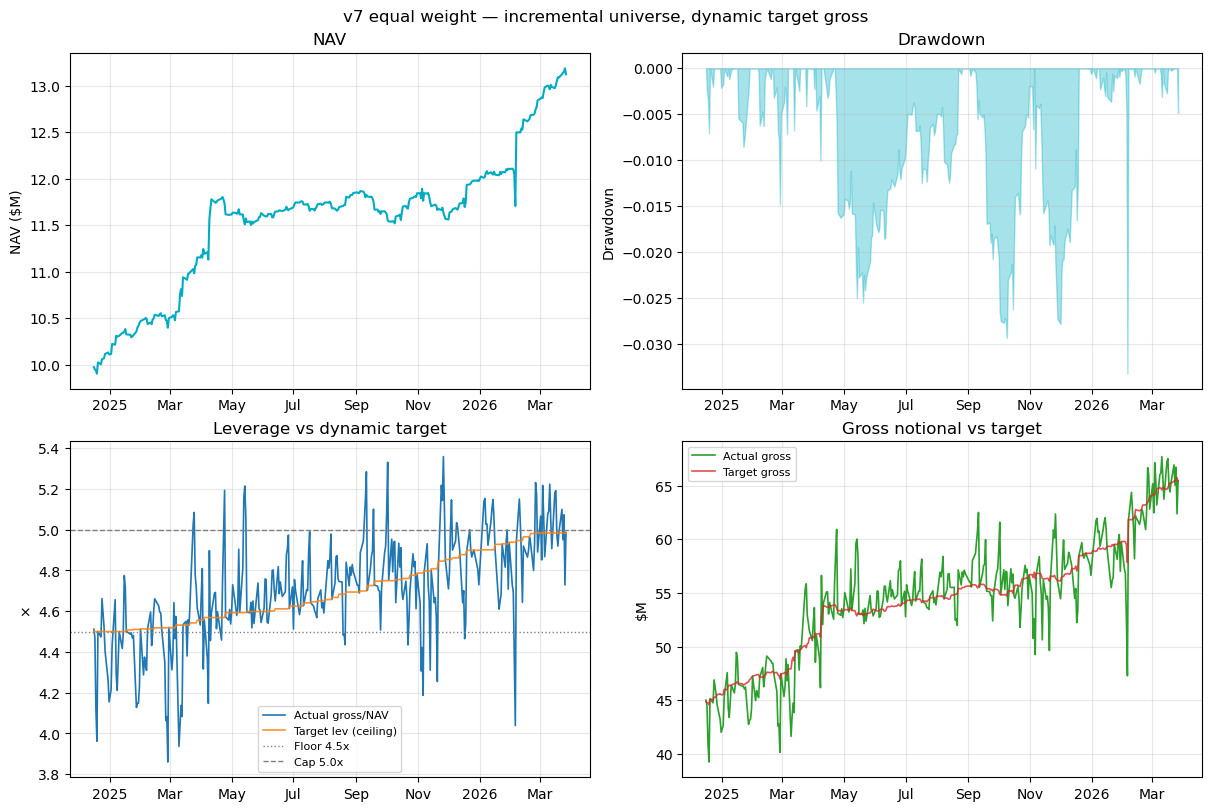

In [123]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ref = max(LEVERAGE_RUNS)
bt = ALL_BT[ref]
fig, axes = plt.subplots(2, 2, figsize=(12, 8), layout="constrained")
fig.suptitle("v7 equal weight — incremental universe, dynamic target gross")

ax = axes[0, 0]
ax.plot(bt.index, bt["nav"] / 1e6, color="#00ACC1", lw=1.5)
ax.set_ylabel("NAV ($M)"); ax.set_title("NAV"); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
nav = bt["nav"]
dd = (nav - nav.cummax()) / nav.cummax()
ax.fill_between(dd.index, dd, 0, alpha=0.35, color="#00ACC1")
ax.set_ylabel("Drawdown"); ax.set_title("Drawdown"); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.plot(bt.index, bt["actual_leverage"], label="Actual gross/NAV", color="tab:blue", lw=1.2)
ax.plot(bt.index, bt["target_lev"], label="Target lev (ceiling)", color="tab:orange", lw=1.2, alpha=0.85)
ax.axhline(V7_TARGET_LEV_START, color="gray", ls=":", lw=1, label=f"Floor {V7_TARGET_LEV_START}x")
ax.axhline(V7_TARGET_LEV_END, color="gray", ls="--", lw=1, label=f"Cap {V7_TARGET_LEV_END}x")
ax.set_ylabel("×"); ax.set_title("Leverage vs dynamic target"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(bt.index, bt["gross_notional"] / 1e6, label="Actual gross", color="tab:green", lw=1.2)
ax.plot(bt.index, bt["tgt_gross_nav"] / 1e6, label="Target gross", color="tab:red", lw=1.2, alpha=0.8)
ax.set_ylabel("$M"); ax.set_title("Gross notional vs target"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

for ax in axes.flat:
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
plt.show()


## v8 Diamond Creek Fund Weights (PnL/Gross + NET Decay + Shares Cap)

Saves the **equal-weight** run to `EW_*`, writes **`data/backtest/v8_pnl_decay_shares_weights.csv`**, and then re-runs the same engine with those `PAIR_WEIGHTS` loaded as the **Diamond Creek Fund** sizing profile.

Construction summary:
- `PnL/Gross` component from the equal-weight v8 run
- `decay` component from `data/etf_screened_today.csv` using `decay_score`
- convex blend using `CFG['mix_decay_weight']`
- shares-availability capacity cap from `shares_available` and `CFG['short_avail_use_pct']`
- cap-ramp schedule: constrained names step up over `CFG['cap_ramp_rebals']` rebalances toward max allowed weight


In [124]:
# ---- Save equal-weight v8 results & compute combined weights ----
EW_BT = dict(ALL_BT)
EW_PAIR_PNL = dict(ALL_PAIR_PNL)
EW_PAIR_NET = dict(ALL_PAIR_NET)
EW_PAIR_GROSS = dict(ALL_PAIR_GROSS)

out = Path("data/backtest")
out.mkdir(parents=True, exist_ok=True)
for lev in LEVERAGE_RUNS:
    EW_BT[lev].to_csv(out / f"v8_ew_nav_{lev}x.csv")
print("Equal-weight v8 NAV series saved.")

ref_lev = max(LEVERAGE_RUNS)
ppnl = EW_PAIR_PNL[ref_lev]
pgross = EW_PAIR_GROSS[ref_lev]

pnl_gross = {}
for etf, d in ppnl.items():
    total_pnl = d["long"] + d["short"]
    col = f"{d['und']}/{etf}"
    avg_gross = pgross[col].mean() if col in pgross.columns else 1.0
    ratio = total_pnl / avg_gross if avg_gross > 0 else 0.0
    pnl_gross[etf] = {
        "und": d["und"],
        "pnl": total_pnl,
        "avg_gross": avg_gross,
        "ratio": ratio,
    }

# ---- Load screener decay + shares available ----
screened_path = Path("../data/etf_screened_today.csv")
if not screened_path.exists():
    run_files = sorted(Path("data/runs").glob("*/etf_screened_today.csv"))
    if not run_files:
        raise FileNotFoundError("Could not find data/etf_screened_today.csv or data/runs/*/etf_screened_today.csv")
    screened_path = run_files[-1]

screen = pd.read_csv(screened_path)
screen.columns = [str(c).strip() for c in screen.columns]
if "ETF" not in screen.columns:
    raise KeyError("Screener file must include an ETF column")

screen["ETF"] = screen["ETF"].astype(str).str.upper()

decay_col = "decay_score"
if decay_col not in screen.columns:
    raise KeyError("Screener file missing required decay_score column")

screen[decay_col] = pd.to_numeric(screen[decay_col], errors="coerce").fillna(0.0)
if "net_decay_annual" in screen.columns:
    screen["net_decay_annual"] = pd.to_numeric(screen["net_decay_annual"], errors="coerce").fillna(0.0)
else:
    screen["net_decay_annual"] = np.nan

if "shares_available" in screen.columns:
    screen["shares_available"] = pd.to_numeric(screen["shares_available"], errors="coerce")
else:
    screen["shares_available"] = np.nan

# Optional AUM inputs (USD). Prefer explicit AUM, then AUM_M, then vendor asset fields.
if "AUM" in screen.columns:
    screen["aum_usd"] = pd.to_numeric(screen["AUM"], errors="coerce")
elif "AUM_M" in screen.columns:
    screen["aum_usd"] = pd.to_numeric(screen["AUM_M"], errors="coerce") * 1e6
elif "totalAssets" in screen.columns:
    screen["aum_usd"] = pd.to_numeric(screen["totalAssets"], errors="coerce")
elif "netAssets" in screen.columns:
    screen["aum_usd"] = pd.to_numeric(screen["netAssets"], errors="coerce")
else:
    screen["aum_usd"] = np.nan

screen["aum_usd"] = pd.to_numeric(screen["aum_usd"], errors="coerce")
screen.loc[screen["aum_usd"] <= 0, "aum_usd"] = np.nan
screen["aum_source"] = np.where(screen["aum_usd"].notna(), "screen", "missing")

# Backfill missing AUM from yfinance with a local cache.
missing_aum = screen["aum_usd"].isna()
if missing_aum.any():
    try:
        import yfinance as yf

        aum_cache_path = Path("data/backtest/etf_aum_cache.csv")
        aum_cache_path.parent.mkdir(parents=True, exist_ok=True)
        if aum_cache_path.exists():
            aum_cache = pd.read_csv(aum_cache_path)
            if not {"ETF", "aum_usd"}.issubset(aum_cache.columns):
                aum_cache = pd.DataFrame(columns=["ETF", "aum_usd"])
        else:
            aum_cache = pd.DataFrame(columns=["ETF", "aum_usd"])

        if not aum_cache.empty:
            aum_cache["ETF"] = aum_cache["ETF"].astype(str).str.upper().str.strip()
            aum_cache["aum_usd"] = pd.to_numeric(aum_cache["aum_usd"], errors="coerce")
            cache_map = dict(zip(aum_cache["ETF"], aum_cache["aum_usd"]))
            from_cache = screen["ETF"].map(cache_map)
            use_cache = missing_aum & from_cache.notna() & (from_cache > 0)
            screen.loc[use_cache, "aum_usd"] = from_cache[use_cache]
            screen.loc[use_cache, "aum_source"] = "cache"

        still_missing = screen["aum_usd"].isna()
        if still_missing.any():
            fetch_syms = sorted(screen.loc[still_missing, "ETF"].dropna().astype(str).str.upper().unique())
            fetched = []
            for t in fetch_syms:
                q = t.replace(".", "-")
                val = np.nan
                try:
                    tk = yf.Ticker(q)
                    fi = getattr(tk, "fast_info", {}) or {}
                    if isinstance(fi, dict):
                        for k in ("total_assets", "totalAssets", "net_assets", "netAssets", "market_cap", "marketCap"):
                            v = fi.get(k)
                            if v is not None and pd.notna(v) and float(v) > 0:
                                val = float(v)
                                break
                    if pd.isna(val):
                        info = tk.info or {}
                        for k in ("totalAssets", "netAssets", "fundAssets", "marketCap"):
                            v = info.get(k)
                            if v is not None and pd.notna(v) and float(v) > 0:
                                val = float(v)
                                break
                except Exception:
                    pass

                if pd.notna(val) and val > 0:
                    fetched.append((t, float(val)))

            if fetched:
                fetched_df = pd.DataFrame(fetched, columns=["ETF", "aum_usd"])
                fetch_map = dict(zip(fetched_df["ETF"], fetched_df["aum_usd"]))
                from_fetch = screen["ETF"].map(fetch_map)
                use_fetch = screen["aum_usd"].isna() & from_fetch.notna() & (from_fetch > 0)
                screen.loc[use_fetch, "aum_usd"] = from_fetch[use_fetch]
                screen.loc[use_fetch, "aum_source"] = "yfinance"

                aum_cache = pd.concat([aum_cache, fetched_df], ignore_index=True)
                aum_cache = aum_cache.dropna(subset=["ETF"]).copy()
                aum_cache["ETF"] = aum_cache["ETF"].astype(str).str.upper().str.strip()
                aum_cache["aum_usd"] = pd.to_numeric(aum_cache["aum_usd"], errors="coerce")
                aum_cache = aum_cache[aum_cache["aum_usd"].notna() & (aum_cache["aum_usd"] > 0)]
                aum_cache = aum_cache.drop_duplicates(subset=["ETF"], keep="last").sort_values("ETF")
                aum_cache.to_csv(aum_cache_path, index=False)
    except Exception:
        pass

# Historical average shares_available by ticker (mean over each ticker's observed days).
runs_candidates = [
    Path("../data/runs"),
    Path("data/runs"),
    Path.cwd() / "../data/runs",
    Path.cwd() / "data/runs",
    Path.cwd().parent / "data/runs",
]
runs_root = None
for cand in runs_candidates:
    c = cand.resolve()
    if c.exists():
        runs_root = c
        break

shares_hist = []
if runs_root is not None:
    run_files = sorted(runs_root.glob("*/etf_screened_today.csv"))
    for rf in run_files:
        try:
            d = pd.read_csv(rf)
        except Exception:
            continue
        if "ETF" not in d.columns:
            continue
        d["ETF"] = d["ETF"].astype(str).str.upper()
        if "shares_available" in d.columns:
            d["shares_available"] = pd.to_numeric(d["shares_available"], errors="coerce")
        else:
            d["shares_available"] = np.nan
        d = d[["ETF", "shares_available"]].rename(columns={"ETF": "etf"})
        d["run_date"] = rf.parent.name
        shares_hist.append(d)

if shares_hist:
    sh = pd.concat(shares_hist, ignore_index=True)
    sh_agg = (
        sh.groupby("etf", dropna=False)["shares_available"]
        .agg(shares_available_avg="mean", shares_obs="count")
        .reset_index()
    )
    sh_agg["shares_obs"] = sh_agg["shares_obs"].astype(int)
    screen = screen.merge(sh_agg, left_on="ETF", right_on="etf", how="left")
    screen.drop(columns=["etf"], inplace=True)
else:
    screen["shares_available_avg"] = np.nan
    screen["shares_obs"] = 0

screen["shares_obs"] = pd.to_numeric(screen.get("shares_obs"), errors="coerce").fillna(0).astype(int)
screen["shares_available_for_cap"] = np.where(
    screen["shares_obs"] > 0,
    screen["shares_available_avg"],
    screen["shares_available"],
)

# Final non-NA AUM fill: underlying median, then global median.
known_aum = screen.loc[screen["aum_usd"].notna() & (screen["aum_usd"] > 0), "aum_usd"]
global_med_aum = float(known_aum.median()) if len(known_aum) else np.nan

if "Underlying" in screen.columns:
    und_med = (
        screen.loc[screen["aum_usd"].notna() & (screen["aum_usd"] > 0)]
        .groupby("Underlying", dropna=False)["aum_usd"]
        .median()
    )
    und_fill = screen["Underlying"].map(und_med)
    use_und = screen["aum_usd"].isna() & und_fill.notna() & (und_fill > 0)
    screen.loc[use_und, "aum_usd"] = und_fill[use_und]
    screen.loc[use_und, "aum_source"] = "underlying_median"

if pd.notna(global_med_aum) and global_med_aum > 0:
    use_global = screen["aum_usd"].isna()
    screen.loc[use_global, "aum_usd"] = global_med_aum
    screen.loc[use_global, "aum_source"] = "global_median"

# Hard fallback to avoid NA in reporting tables.
use_zero = screen["aum_usd"].isna()
if use_zero.any():
    screen.loc[use_zero, "aum_usd"] = 0.0
    screen.loc[use_zero, "aum_source"] = "fallback_zero"

screen["aum_usd"] = pd.to_numeric(screen["aum_usd"], errors="coerce").fillna(0.0)

screener_map = screen.set_index("ETF")[[
    decay_col,
    "net_decay_annual",
    "shares_available",
    "shares_available_avg",
    "shares_available_for_cap",
    "shares_obs",
    "aum_usd",
    "aum_source",
]].to_dict("index")

ranked = sorted(pnl_gross.items(), key=lambda x: x[1]["ratio"], reverse=True)

pw = CFG.get("weight_power", 2)
decay_pw = CFG.get("decay_weight_power", 1.25)
mix_decay = float(CFG.get("mix_decay_weight", 0.45))
mix_decay = min(1.0, max(0.0, mix_decay))

etfs = [etf for etf, _ in ranked]
pnl_component = pd.Series({etf: max(0.0, pnl_gross[etf]["ratio"]) ** pw for etf in etfs}, dtype=float)
decay_component = pd.Series(
    {etf: max(0.0, float(screener_map.get(etf, {}).get(decay_col, 0.0))) ** decay_pw for etf in etfs},
    dtype=float,
)

if pnl_component.sum() <= 0:
    pnl_component[:] = 1.0
if decay_component.sum() <= 0:
    decay_component[:] = 1.0

pnl_norm = pnl_component / pnl_component.sum()
decay_norm = decay_component / decay_component.sum()
raw_weight = (1.0 - mix_decay) * pnl_norm + mix_decay * decay_norm
raw_weight = raw_weight / raw_weight.sum()

# Optional concentration tilt: increase allocation to largest signals.
conc_pw = float(CFG.get("position_concentration_power", 1.0))
if conc_pw > 1.0:
    raw_weight = raw_weight.pow(conc_pw)
    if raw_weight.sum() > 0:
        raw_weight = raw_weight / raw_weight.sum()

# ---- Capacity caps from shares_available ----
beta_map = {etf: abs(bv) for etf, _, bv in UNIVERSE}
ref_date = EW_BT[ref_lev].index[-1]
ref_tgt_gross = float(EW_BT[ref_lev]["tgt_gross_nav"].iloc[-1])
short_avail_use_pct = float(CFG.get("short_avail_use_pct", 0.10))
max_pair_weight_cap = float(CFG.get("max_pair_weight_cap", 0.20))
missing_shares_cap = float(CFG.get("missing_shares_cap", 0.01))

# For table translation from weights -> dollars.
assumed_nav_usd = float(CFG.get("capital_usd", 10_000_000))
assumed_target_lev = float(EW_BT[ref_lev]["target_lev"].iloc[-1]) if "target_lev" in EW_BT[ref_lev].columns else float(V7_TARGET_LEV_END)
assumed_target_gross_usd = assumed_nav_usd * assumed_target_lev

cap_frac = {}
for etf in etfs:
    babs = max(1e-9, beta_map.get(etf, 2.0))
    hr = 1.0 / babs
    short_frac = hr / (1.0 + hr)

    px_ser = PRICES.get(etf)
    px_e = float(px_ser.asof(ref_date)) if px_ser is not None else np.nan
    sh_av = screener_map.get(etf, {}).get("shares_available_for_cap", np.nan)

    if pd.isna(sh_av) or sh_av <= 0 or pd.isna(px_e) or px_e <= 0:
        cap = missing_shares_cap
    else:
        cap_shares = float(sh_av) * short_avail_use_pct
        cap = (cap_shares * px_e) / max(1.0, ref_tgt_gross * short_frac)

    cap_frac[etf] = min(max_pair_weight_cap, max(0.0, cap))

cap_s = pd.Series(cap_frac, dtype=float)

# If strict caps are infeasible, minimally relax toward desired weights.
if cap_s.sum() < 1.0:
    cap_s = np.maximum(cap_s, raw_weight)


def project_to_capped_simplex(desired: pd.Series, caps: pd.Series, tol: float = 1e-12) -> pd.Series:
    """Project desired weights onto {w>=0, w<=caps, sum(w)=1}.

    This keeps final weights <= caps whenever feasible.
    """
    desired = desired.astype(float).copy()
    caps = caps.astype(float).copy().clip(lower=0.0)

    if desired.sum() <= 0:
        desired[:] = 1.0
    desired = desired / desired.sum()

    # Ensure feasibility (sum caps must be >= 1).
    if caps.sum() < 1.0:
        caps = np.maximum(caps, desired)

    w = pd.Series(0.0, index=desired.index)
    free = list(desired.index)
    remaining = 1.0

    while free and remaining > tol:
        base = desired.loc[free]
        if base.sum() <= 0:
            trial = pd.Series(remaining / len(free), index=free)
        else:
            trial = remaining * base / base.sum()

        hit = trial > (caps.loc[free] + tol)
        if not hit.any():
            w.loc[free] = trial
            remaining = 0.0
            break

        hit_idx = list(trial.index[hit])
        w.loc[hit_idx] = caps.loc[hit_idx]
        remaining = 1.0 - float(w.sum())
        free = [k for k in free if k not in hit_idx]

    # Safety: fill any tiny remainder by available headroom.
    if remaining > tol and free:
        room = (caps.loc[free] - w.loc[free]).clip(lower=0.0)
        if room.sum() > tol:
            w.loc[free] += remaining * room / room.sum()

    w = w.clip(lower=0.0)
    if w.sum() <= 0:
        w = desired.copy()

    w = w / w.sum()
    w = np.minimum(w, caps)

    # Final small renorm without violating caps.
    rem = 1.0 - float(w.sum())
    if rem > tol:
        room = (caps - w).clip(lower=0.0)
        if room.sum() > tol:
            w += rem * room / room.sum()
    if w.sum() > 0:
        w = w / w.sum()
    return w


final_weight = project_to_capped_simplex(raw_weight, cap_s)
weights_dict = final_weight.to_dict()

print(f"Using screener: {screened_path}")
if runs_root is not None:
    print(f"Shares-average history root: {runs_root}")
print(
    f"Decay column: {decay_col} | mix_decay_weight={mix_decay:.2f} | "
    f"weight_power={pw} | decay_weight_power={decay_pw} | concentration_power={conc_pw:.2f}"
)
print(
    f"Shares cap: use={short_avail_use_pct:.1%}, hard pair cap={max_pair_weight_cap:.1%}, "
    f"missing_shares_cap={missing_shares_cap:.1%}"
)
print(
    f"Shares source for cap: per-ticker historical mean where available "
    f"(tickers with history: {(screen['shares_obs'] > 0).sum()}/{len(screen)})"
)
print(
    f"Dollar translation assumptions: NAV=${assumed_nav_usd:,.0f}, "
    f"target gross={assumed_target_lev:.2f}x -> ${assumed_target_gross_usd:,.0f}"
)
print(
    f"AUM availability after fill: {screen['aum_usd'].notna().sum()}/{len(screen)} tickers | "
    f"sources: screen={(screen['aum_source']=='screen').sum()}, cache={(screen['aum_source']=='cache').sum()}, "
    f"yfinance={(screen['aum_source']=='yfinance').sum()}, underlying_med={(screen['aum_source']=='underlying_median').sum()}, "
    f"global_med={(screen['aum_source']=='global_median').sum()}, zero_fallback={(screen['aum_source']=='fallback_zero').sum()}"
)
print(f"Top 5 concentration: {sum(sorted(weights_dict.values(), reverse=True)[:5]):.1%}")
print(f"Top 10 concentration: {sum(sorted(weights_dict.values(), reverse=True)[:10]):.1%}")

w_rows = []
for etf, d in ranked:
    sh_cur = screener_map.get(etf, {}).get("shares_available", np.nan)
    sh_avg = screener_map.get(etf, {}).get("shares_available_avg", np.nan)
    sh_cap = screener_map.get(etf, {}).get("shares_available_for_cap", np.nan)
    sh_obs = int(screener_map.get(etf, {}).get("shares_obs", 0) or 0)
    dcol_val = float(screener_map.get(etf, {}).get(decay_col, 0.0))
    nd_val = float(screener_map.get(etf, {}).get("net_decay_annual", np.nan))
    aum_usd = float(screener_map.get(etf, {}).get("aum_usd", np.nan))
    aum_source = str(screener_map.get(etf, {}).get("aum_source", "missing"))

    babs = max(1e-9, beta_map.get(etf, 2.0))
    hr = 1.0 / babs
    short_frac = hr / (1.0 + hr)
    px_ser = PRICES.get(etf)
    px_e = float(px_ser.asof(ref_date)) if px_ser is not None else np.nan

    pair_target_gross_usd = float(weights_dict.get(etf, 0.0)) * assumed_target_gross_usd
    short_target_usd = pair_target_gross_usd * short_frac
    max_short_capacity_usd_full = (float(sh_cap) * float(px_e)) if (pd.notna(sh_cap) and pd.notna(px_e) and sh_cap > 0 and px_e > 0) else np.nan
    max_short_capacity_usd_used = (
        float(sh_cap) * short_avail_use_pct * float(px_e)
        if (pd.notna(sh_cap) and pd.notna(px_e) and sh_cap > 0 and px_e > 0)
        else np.nan
    )

    w_rows.append(
        {
            "etf": etf,
            "und": d["und"],
            "pnl": d["pnl"],
            "avg_gross": d["avg_gross"],
            "ratio": d["ratio"],
            "decay_col": decay_col,
            "decay_value": dcol_val,
            "net_decay_annual": nd_val,
            "shares_available": sh_cur,
            "shares_available_avg": sh_avg,
            "shares_available_for_cap": sh_cap,
            "shares_obs": sh_obs,
            "aum_usd": aum_usd,
            "aum_m": aum_usd / 1e6 if pd.notna(aum_usd) else np.nan,
            "aum_source": aum_source,
            "etf_price": px_e,
            "short_frac": short_frac,
            "pair_target_gross_usd": pair_target_gross_usd,
            "short_target_usd": short_target_usd,
            "max_short_capacity_usd_full": max_short_capacity_usd_full,
            "max_short_capacity_usd_used": max_short_capacity_usd_used,
            "short_capacity_utilization": (short_target_usd / max_short_capacity_usd_used) if (pd.notna(max_short_capacity_usd_used) and max_short_capacity_usd_used > 0) else np.nan,
            "pnl_component": float(pnl_component.get(etf, 0.0)),
            "decay_component": float(decay_component.get(etf, 0.0)),
            "weight_raw": float(raw_weight.get(etf, 0.0)),
            "weight_cap": float(cap_s.get(etf, 0.0)),
            "weight": float(weights_dict.get(etf, 0.0)),
            "cap_binding": int(final_weight.get(etf, 0.0) >= cap_s.get(etf, 0.0) - 1e-9),
        }
    )

w_df = pd.DataFrame(w_rows)
w_df.to_csv(out / "v8_pnl_decay_shares_weights.csv", index=False)
print(f"Saved {len(w_df)} pair weights to v8_pnl_decay_shares_weights.csv")

print("\nv8 Diamond Creek Fund weighting (PnL/Gross + decay, capped by shares availability)")
print(
    f"{'Rank':>4s}  {'Pair':>18s}  {'Final W':>8s}  {'AUM($M)':>9s}  {'AUM Src':>9s}  {'ETF Px':>8s}  {'Shares(avg)':>12s}  {'Obs':>4s}  "
    f"{'Short$@10m':>11s}  {'ShAvg*Px$':>11s}  {'Use%Cap$':>11s}  {'Util':>7s}"
)
print(f"  {'-'*161}")
for i, row in enumerate(w_df.sort_values("weight", ascending=False).itertuples(index=False), 1):
    pair = f"{row.und}/{row.etf}"
    aum_txt = "NA" if pd.isna(row.aum_m) else f"{row.aum_m:,.0f}"
    aum_src_txt = str(row.aum_source)[:9]
    px_txt = "NA" if pd.isna(row.etf_price) else f"{row.etf_price:,.2f}"
    sh_txt = "NA" if pd.isna(row.shares_available_for_cap) else f"{row.shares_available_for_cap:,.0f}"
    short_txt = "NA" if pd.isna(row.short_target_usd) else f"{row.short_target_usd:,.0f}"
    full_cap_txt = "NA" if pd.isna(row.max_short_capacity_usd_full) else f"{row.max_short_capacity_usd_full:,.0f}"
    use_cap_txt = "NA" if pd.isna(row.max_short_capacity_usd_used) else f"{row.max_short_capacity_usd_used:,.0f}"
    util_txt = "NA" if pd.isna(row.short_capacity_utilization) else f"{row.short_capacity_utilization:,.0%}"
    print(
        f"  {i:3d}  {pair:>18s}  {row.weight:>7.2%}  {aum_txt:>9s}  {aum_src_txt:>9s}  {px_txt:>8s}  {sh_txt:>12s}  {int(row.shares_obs):>4d}  "
        f"{short_txt:>11s}  {full_cap_txt:>11s}  {use_cap_txt:>11s}  {util_txt:>7s}"
    )


Equal-weight v8 NAV series saved.
Using screener: ..\data\etf_screened_today.csv
Shares-average history root: C:\Users\werdn\Documents\Investing\ls-algo\data\runs
Decay column: decay_score | mix_decay_weight=0.45 | weight_power=2 | decay_weight_power=1.25 | concentration_power=1.35
Shares cap: use=25.0%, hard pair cap=20.0%, missing_shares_cap=3.0%
Shares source for cap: per-ticker historical mean where available (tickers with history: 383/383)
Dollar translation assumptions: NAV=$10,000,000, target gross=4.98x -> $49,840,426
AUM availability after fill: 383/383 tickers | sources: screen=0, cache=358, yfinance=0, underlying_med=16, global_med=9, zero_fallback=0
Top 5 concentration: 18.0%
Top 10 concentration: 27.1%
Saved 246 pair weights to v8_pnl_decay_shares_weights.csv

v8 Diamond Creek Fund weighting (PnL/Gross + decay, capped by shares availability)
Rank                Pair   Final W    AUM($M)    AUM Src    ETF Px   Shares(avg)   Obs   Short$@10m    ShAvg*Px$     Use%Cap$     Uti

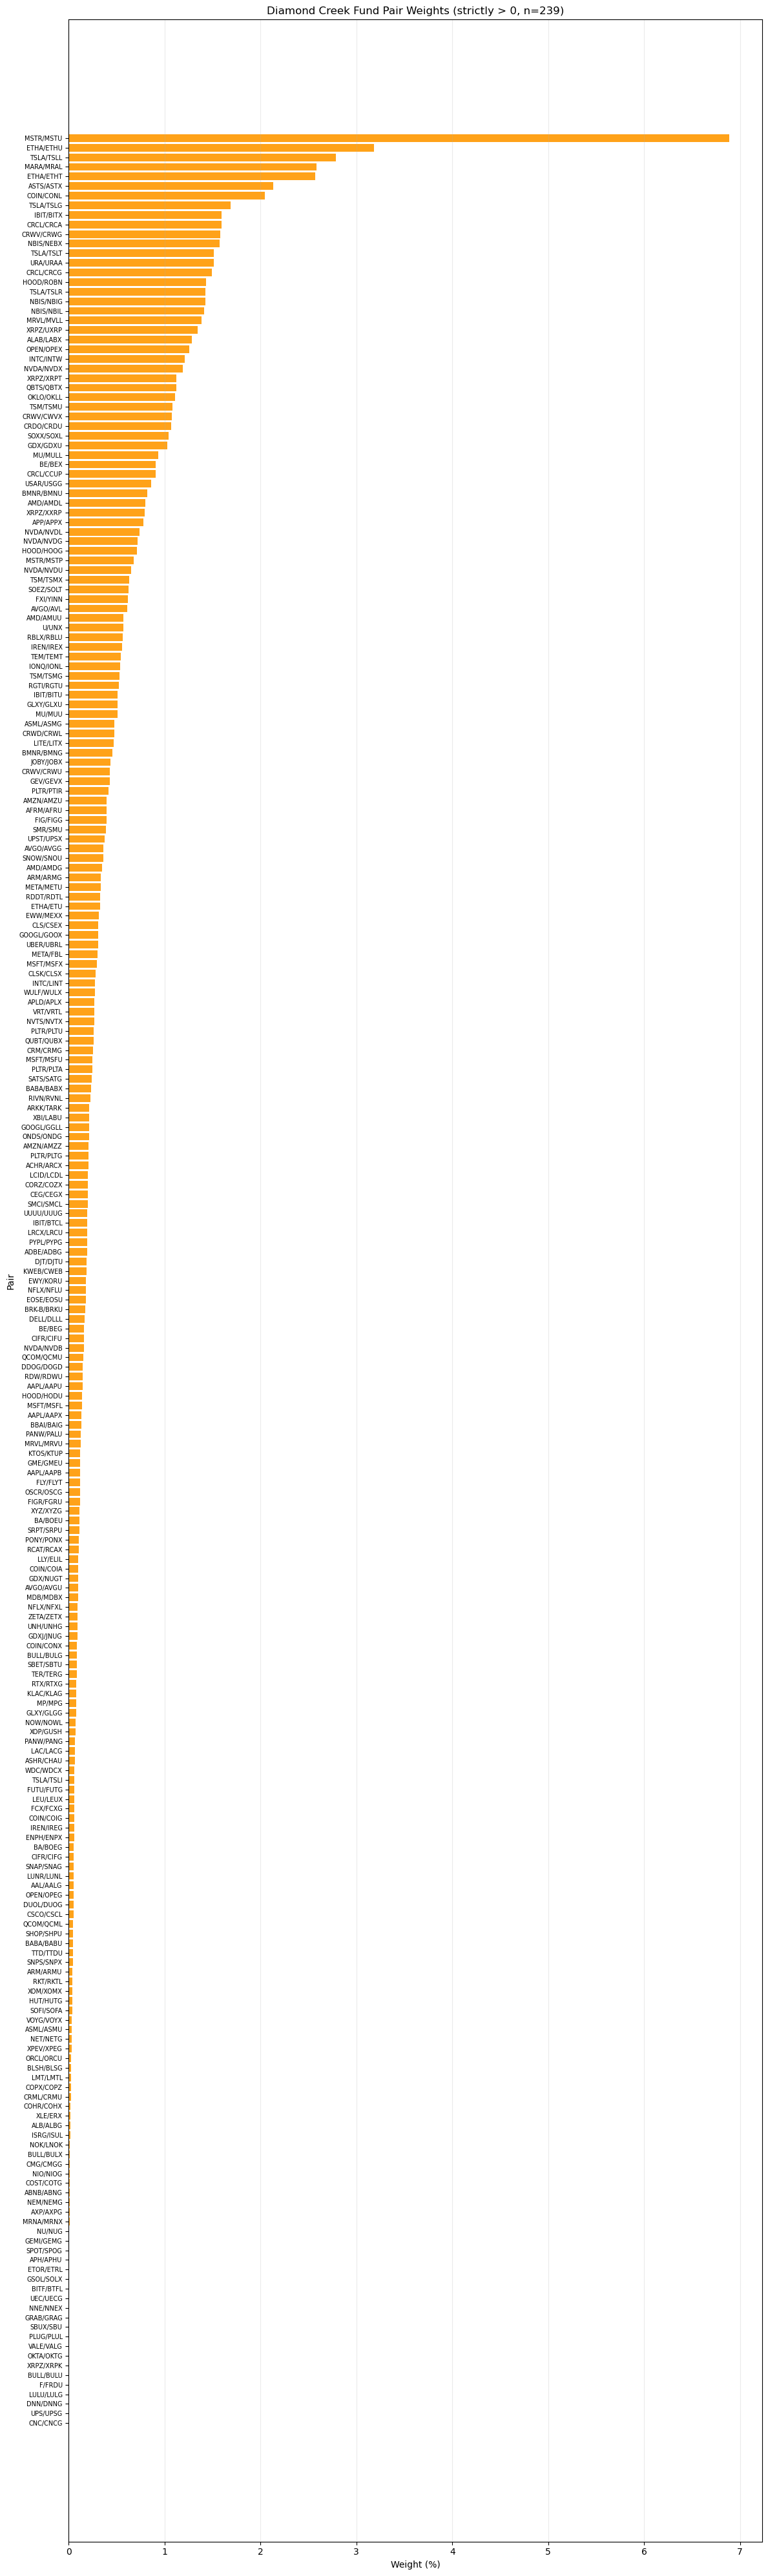

In [125]:
# ---- Diamond Creek Fund: pair-level weights bar chart (strictly > 0) ----
import matplotlib.pyplot as plt

if "w_df" not in globals() or w_df.empty:
    raise RuntimeError("Run the Diamond Creek weighting cell first (w_df not found).")

pair_w = w_df.loc[w_df["weight"] > 0, ["und", "etf", "weight"]].copy()
if pair_w.empty:
    raise RuntimeError("No strictly positive weights found.")

pair_w["pair"] = pair_w["und"].astype(str) + "/" + pair_w["etf"].astype(str)
pair_w = pair_w.sort_values("weight", ascending=True).reset_index(drop=True)

n = len(pair_w)
fig_h = min(40, max(8, 0.26 * n))
fig, ax = plt.subplots(figsize=(12, fig_h))

ax.barh(pair_w["pair"], pair_w["weight"] * 100.0, color="#FF9800", alpha=0.9)
ax.set_title(f"Diamond Creek Fund Pair Weights (strictly > 0, n={n})")
ax.set_xlabel("Weight (%)")
ax.set_ylabel("Pair")
ax.grid(True, axis="x", alpha=0.25)
ax.tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.show()


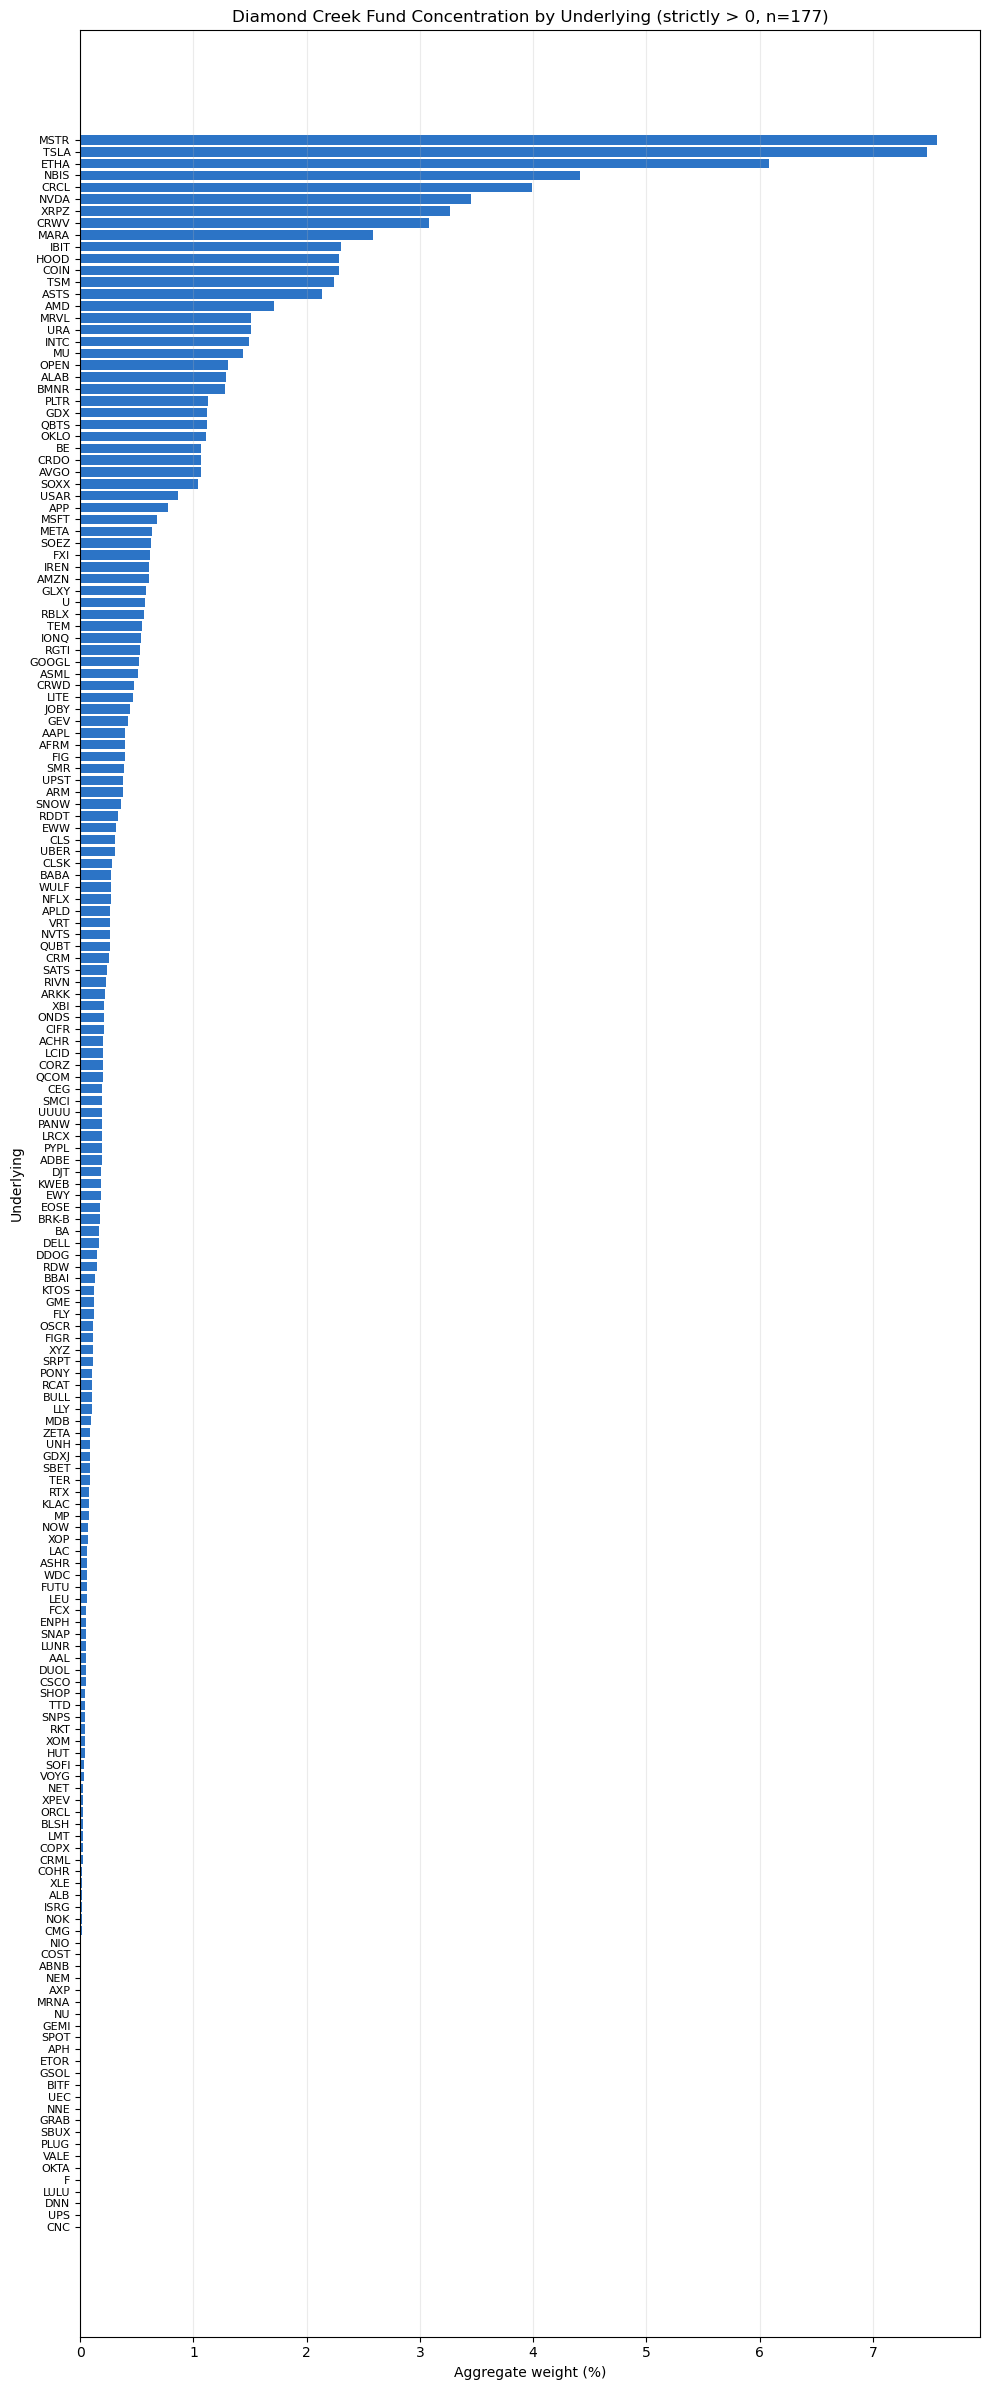

In [126]:
# ---- Diamond Creek Fund: concentration by unique underlying ----
import matplotlib.pyplot as plt

if "w_df" not in globals() or w_df.empty:
    raise RuntimeError("Run the Diamond Creek weighting cell first (w_df not found).")

und_w = (
    w_df.loc[w_df["weight"] > 0, ["und", "weight"]]
    .groupby("und", as_index=False)["weight"]
    .sum()
    .sort_values("weight", ascending=True)
)

if und_w.empty:
    raise RuntimeError("No strictly positive weights found for underlying concentration.")

n = len(und_w)
fig_h = min(24, max(6, 0.24 * n))
fig, ax = plt.subplots(figsize=(10, fig_h))

ax.barh(und_w["und"], und_w["weight"] * 100.0, color="#1565C0", alpha=0.9)
ax.set_title(f"Diamond Creek Fund Concentration by Underlying (strictly > 0, n={n})")
ax.set_xlabel("Aggregate weight (%)")
ax.set_ylabel("Underlying")
ax.grid(True, axis="x", alpha=0.25)
ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()


In [128]:
_w_csv = pd.read_csv(Path("data/backtest/v8_pnl_decay_shares_weights.csv"))
PAIR_WEIGHTS = dict(zip(_w_csv["etf"], _w_csv["weight"]))

# Optional cap-ramp support: increase allowed cap over the next N rebalances.
CAP_RAMP_REBALS = int(CFG.get("cap_ramp_rebals", 3))
max_pair_weight_cap = float(CFG.get("max_pair_weight_cap", 0.20))
if {"etf", "weight", "weight_raw"}.issubset(_w_csv.columns):
    _wtmp = _w_csv.copy()
    _wtmp["etf"] = _wtmp["etf"].astype(str).str.upper()
    PAIR_WEIGHT_BASE = dict(zip(_wtmp["etf"], _wtmp["weight"]))
    PAIR_WEIGHT_MAX = dict(zip(_wtmp["etf"], np.minimum(_wtmp["weight_raw"], max_pair_weight_cap)))
else:
    PAIR_WEIGHT_BASE = dict(PAIR_WEIGHTS)
    PAIR_WEIGHT_MAX = dict(PAIR_WEIGHTS)

print(f"Loaded v8 Diamond Creek Fund weights: {len(PAIR_WEIGHTS)} pairs")
print(f"  Top weight: {max(PAIR_WEIGHTS.values()):.2%} | Bottom: {min(v for v in PAIR_WEIGHTS.values() if v > 0):.2%}")
print(f"  Top 5 concentration: {sum(sorted(PAIR_WEIGHTS.values(), reverse=True)[:5]):.1%}")
print(f"  Top 10 concentration: {sum(sorted(PAIR_WEIGHTS.values(), reverse=True)[:10]):.1%}")
print(f"  Cap ramp rebalances: {CAP_RAMP_REBALS}")
_top5 = sorted(PAIR_WEIGHTS.items(), key=lambda x: x[1], reverse=True)[:5]
for _etf, _w in _top5:
    print(f"    {_etf:>6s}: {_w:.2%}")
print()
print("=" * 60)
print("  v8 — Diamond Creek Fund weighted run (same engine; PAIR_WEIGHTS from CSV)")
print("=" * 60)

spy = PRICES.get("SPY")
tdays = spy.index[spy.index >= start_ts].sort_values()

s = pd.Series(range(len(tdays)), index=tdays)
rebal_idx = s.resample("W-FRI").last().dropna()
rebal_days = set(tdays[int(i)] for i in rebal_idx.values)

n_pairs = len(UNIVERSE)
INC_ETFS = frozenset(
    etf for etf, und, bv in UNIVERSE if INCEPTION[(etf, und)] <= start_ts
)
POST_ETFS = frozenset(
    etf for etf, und, bv in UNIVERSE if INCEPTION[(etf, und)] > start_ts
)

print(f"Trading days: {len(tdays)} | Rebalance days: {len(rebal_days)} (weekly)")
print(f"Pairs: {n_pairs} | Incumbents (≤ start): {len(INC_ETFS)} | Post-start: {len(POST_ETFS)}")
print(f"Start: {tdays[0].strftime('%Y-%m-%d')} | End: {tdays[-1].strftime('%Y-%m-%d')}")
print(
    f"v8 target gross multiple: {V7_TARGET_LEV_START}x → {V7_TARGET_LEV_END}x "
    f"as post-start pairs join (v5-style incumbent hedging + dead-band gross control)"
)

if "PAIR_WEIGHTS" not in dir():
    PAIR_WEIGHTS = {e: 1.0 / n_pairs for e, _, _ in UNIVERSE}
    print(f"Using equal weights: {1.0/n_pairs:.4%} per pair")
else:
    print(f"Using custom PAIR_WEIGHTS ({len(PAIR_WEIGHTS)} pairs, top weight: {max(PAIR_WEIGHTS.values()):.2%})")

ALL_BT = {}
ALL_PAIR_PNL = {}
ALL_PAIR_NET = {}
ALL_PAIR_GROSS = {}

for gross_lev in LEVERAGE_RUNS:
    print(f"\n{'='*60}")
    print(
        f"  v7 RUN (store key {gross_lev}x) | dynamic tgt gross {V7_TARGET_LEV_START}x–{V7_TARGET_LEV_END}x"
    )
    print(f"{'='*60}")

    cash = float(CFG["capital_usd"])
    holdings = {}
    pair_pos = {}
    pair_pnl = {}
    daily_rows = []
    tot_costs = tot_borrow = tot_margin_debit = tot_margin_credit = 0.0
    rebal_count = 0
    pair_entry_rebal: dict[tuple[str, str], int] = {}
    pair_cap_entry_rebal: dict[str, int] = {}
    prev_px = {}
    cum_long_pnl = cum_short_pnl = 0.0
    pair_net_rows = []
    pair_gross_rows = []

    def _execute_trade(sym, tgt_sh, px_map):
        global cash
        cur_sh = holdings.get(sym, 0)
        delta = tgt_sh - cur_sh
        p = px_map.get(sym, 0)
        trade_usd = abs(delta * p)
        if p <= 0 or trade_usd < 1:
            return 0.0, 0.0
        cash -= delta * p
        c = trade_cost(trade_usd, p, CFG)
        cash -= c
        if abs(tgt_sh) < 1:
            holdings.pop(sym, None)
        else:
            holdings[sym] = tgt_sh
        return trade_usd, c

    def _frac_rows_for_day(today, R: int):
        rows = []
        for etf, und, bv in UNIVERSE:
            key = (etf, und)
            if INCEPTION[key] > today:
                continue

            # Existing listing ramp-in from v7/v8 engine.
            if INCEPTION[key] <= start_ts:
                rp = 1.0
            else:
                if key not in pair_entry_rebal:
                    pair_entry_rebal[key] = R
                rp = min(1.0, (R - pair_entry_rebal[key] + 1) / float(RAMP_WEEKS))

            # New cap-ramp: for names that were cap-constrained, allow cap to increase
            # linearly over the next CAP_RAMP_REBALS rebalances toward max allowed weight.
            base_w = float(PAIR_WEIGHT_BASE.get(etf, PAIR_WEIGHTS.get(etf, 1.0 / n_pairs)))
            max_w = float(PAIR_WEIGHT_MAX.get(etf, base_w))
            if max_w > base_w + 1e-12:
                if etf not in pair_cap_entry_rebal:
                    pair_cap_entry_rebal[etf] = R
                cap_prog = min(1.0, (R - pair_cap_entry_rebal[etf] + 1) / float(max(1, CAP_RAMP_REBALS)))
                wb = base_w + (max_w - base_w) * cap_prog
            else:
                wb = base_w

            rows.append((etf, und, bv, wb * rp))
        return rows

    def _pair_gross_usd(ek, px_map):
        pos = pair_pos.get(ek)
        if not pos:
            return 0.0
        uk = pos["und"]
        return max(pos["long_sh"], 0) * px_map.get(
            uk, 0
        ) + max(-pos["short_sh"], 0) * px_map.get(ek, 0)

    def _target_lev_for_book(px_map):
        if not POST_ETFS:
            return float(V7_TARGET_LEV_START)
        on = sum(1 for ek in POST_ETFS if _pair_gross_usd(ek, px_map) > 1.0)
        prog = on / float(len(POST_ETFS))
        return V7_TARGET_LEV_START + (V7_TARGET_LEV_END - V7_TARGET_LEV_START) * prog

    def _apply_allocs(tgt_gross: float, frac_rows, px_map: dict) -> dict:
        tw = sum(r[3] for r in frac_rows)
        tgt_shares: dict = {}
        if tw <= 0:
            return tgt_shares
        for etf, und, bv, wcomb in frac_rows:
            frac = wcomb / tw
            alloc = tgt_gross * frac
            p_u, p_e = px_map.get(und, 0), px_map.get(etf, 0)
            if p_u <= 0 or p_e <= 0:
                continue
            babs = abs(bv)
            hr = 1.0 / babs
            long_usd = alloc / (1.0 + hr)
            short_usd = alloc - long_usd
            lsh = int(round(long_usd / p_u))
            ssh = -int(round(short_usd / p_e))
            pair_pos[etf] = {"und": und, "long_sh": lsh, "short_sh": ssh}
            if etf not in pair_pnl:
                pair_pnl[etf] = {"und": und, "long": 0.0, "short": 0.0}
            tgt_shares[und] = tgt_shares.get(und, 0) + lsh
            tgt_shares[etf] = tgt_shares.get(etf, 0) + ssh
        return tgt_shares

    def _apply_one_pair(
        tgt_shares: dict, etf, und, bv, alloc_usd: float, px_map: dict
    ) -> None:
        p_u, p_e = px_map.get(und, 0), px_map.get(etf, 0)
        if p_u <= 0 or p_e <= 0 or alloc_usd <= 0:
            return
        babs = abs(bv)
        hr = 1.0 / babs
        long_usd = alloc_usd / (1.0 + hr)
        short_usd = alloc_usd - long_usd
        lsh = int(round(long_usd / p_u))
        ssh = -int(round(short_usd / p_e))
        pair_pos[etf] = {"und": und, "long_sh": lsh, "short_sh": ssh}
        if etf not in pair_pnl:
            pair_pnl[etf] = {"und": und, "long": 0.0, "short": 0.0}
        tgt_shares[und] = tgt_shares.get(und, 0) + lsh
        tgt_shares[etf] = tgt_shares.get(etf, 0) + ssh

    for di, today in enumerate(tdays):
        px = {}
        for sym, ser in PRICES.items():
            if today in ser.index:
                px[sym] = float(ser.loc[today])
            else:
                prior = ser[ser.index <= today]
                if not prior.empty:
                    px[sym] = float(prior.iloc[-1])

        daily_long_pnl = daily_short_pnl = 0.0
        if di > 0 and prev_px:
            for ek, pos in pair_pos.items():
                uk = pos["und"]
                dp_u = px.get(uk, 0) - prev_px.get(uk, 0)
                dp_e = px.get(ek, 0) - prev_px.get(ek, 0)
                l_pnl = pos["long_sh"] * dp_u if pos["long_sh"] > 0 else 0.0
                s_pnl = pos["short_sh"] * dp_e if pos["short_sh"] < 0 else 0.0
                daily_long_pnl += l_pnl
                daily_short_pnl += s_pnl
                pair_pnl[ek]["long"] += l_pnl
                pair_pnl[ek]["short"] += s_pnl
        cum_long_pnl += daily_long_pnl
        cum_short_pnl += daily_short_pnl

        mtm = sum(sh * px.get(sym, 0) for sym, sh in holdings.items())
        nav = cash + mtm

        borrow_d = 0.0
        for sym, sh in holdings.items():
            if sh < 0:
                borrow_d += (
                    abs(sh)
                    * px.get(sym, 0)
                    * BORROW_MAP.get(sym, CFG["fallback_borrow_rate"])
                    / TRADING_DAYS
                )
        cash -= borrow_d
        tot_borrow += borrow_d

        ff = _get_fed_funds(today)
        l_notional = sum(
            sh * px.get(sym, 0) for sym, sh in holdings.items() if sh > 0
        )
        s_notional = sum(
            abs(sh) * px.get(sym, 0) for sym, sh in holdings.items() if sh < 0
        )

        long_financing = max(0.0, l_notional - CFG["capital_usd"])
        margin_debit_d = margin_debit_interest(
            long_financing, ff, CFG["margin_debit_spreads"]
        )
        cash -= margin_debit_d
        tot_margin_debit += margin_debit_d

        margin_credit_d = short_credit_interest(
            s_notional, ff, CFG["credit_spread"]
        )
        cash += margin_credit_d
        tot_margin_credit += margin_credit_d

        mtm = sum(sh * px.get(sym, 0) for sym, sh in holdings.items())
        nav = cash + mtm

        trade_turnover = 0.0
        dc = 0.0
        is_rebal = (today in rebal_days) or (di == 0)

        if is_rebal:
            rebal_count += 1
            frac_rows = _frac_rows_for_day(today, rebal_count)
            db = CFG["dead_band_pct"]
            tw = sum(r[3] for r in frac_rows)
            gdb = CFG.get("gross_dead_band_pct", 0.05)

            target_lev_t = _target_lev_for_book(px)
            tgt_gross_nav = nav * target_lev_t

            actual_gross = sum(
                max(p.get("long_sh", 0), 0) * px.get(p["und"], 0)
                + max(-p.get("short_sh", 0), 0) * px.get(ek, 0)
                for ek, p in pair_pos.items()
            )
            gross_drift = (
                abs(actual_gross - tgt_gross_nav) / tgt_gross_nav
                if tgt_gross_nav > 0
                else 0
            )

            tgt_shares: dict = {}

            if di == 0:
                rows0 = [r for r in frac_rows if r[0] in INC_ETFS]
                tw0 = sum(r[3] for r in rows0)
                if tw0 <= 0:
                    raise RuntimeError("v7 day 0: no incumbent frac_rows")
                tgt0 = nav * float(V7_TARGET_LEV_START)
                tgt_shares = _apply_allocs(tgt0, rows0, px)
            else:
                if gross_drift > gdb:
                    tgt_shares = _apply_allocs(tgt_gross_nav, frac_rows, px)
                else:
                    for etf, und, bv in UNIVERSE:
                        if etf not in INC_ETFS:
                            continue
                        pos = pair_pos.get(etf)
                        if pos is None:
                            continue
                        p_u, p_e = px.get(und, 0), px.get(etf, 0)
                        if p_u <= 0 or p_e <= 0:
                            continue
                        babs = abs(bv)
                        l_val = max(pos["long_sh"], 0) * p_u
                        s_val = max(-pos["short_sh"], 0) * p_e
                        pair_gross = l_val + s_val
                        beta_net = l_val - babs * s_val

                        if pair_gross > 0 and abs(beta_net) / pair_gross > db:
                            target_short_usd = l_val / babs
                            new_ssh = -int(round(target_short_usd / p_e))
                            pair_pos[etf]["short_sh"] = new_ssh

                        tgt_shares[und] = tgt_shares.get(und, 0) + pos["long_sh"]
                        tgt_shares[etf] = tgt_shares.get(etf, 0) + pair_pos[etf][
                            "short_sh"
                        ]

                    if tw > 0 and tgt_gross_nav > 0:
                        for etf, und, bv, wcomb in frac_rows:
                            if etf in INC_ETFS:
                                continue
                            alloc = tgt_gross_nav * (wcomb / tw)
                            _apply_one_pair(tgt_shares, etf, und, bv, alloc, px)

            for sym in set(tgt_shares) | set(holdings):
                tusd, tc = _execute_trade(sym, tgt_shares.get(sym, 0), px)
                trade_turnover += tusd
                dc += tc

        tot_costs += dc

        net_row = {"date": today}
        gross_row = {"date": today}
        for ek, pos in pair_pos.items():
            uk = pos["und"]
            l_val = max(pos["long_sh"], 0) * px.get(uk, 0)
            s_val = max(-pos["short_sh"], 0) * px.get(ek, 0)
            net_row[f"{uk}/{ek}"] = l_val - s_val
            gross_row[f"{uk}/{ek}"] = l_val + s_val
        pair_net_rows.append(net_row)
        pair_gross_rows.append(gross_row)

        mtm = sum(sh * px.get(sym, 0) for sym, sh in holdings.items())
        nv = cash + mtm
        l = sum(sh * px.get(sym, 0) for sym, sh in holdings.items() if sh > 0)
        s = sum(abs(sh) * px.get(sym, 0) for sym, sh in holdings.items() if sh < 0)
        actual_gross = l + s

        target_lev_t = _target_lev_for_book(px)
        tgt_gross_nav = nv * target_lev_t

        daily_rows.append(
            {
                "date": today,
                "nav": nv,
                "cash": cash,
                "long_notional": l,
                "short_notional": s,
                "gross_notional": actual_gross,
                "net_notional": l - s,
                "actual_leverage": actual_gross / nv if nv > 0 else np.nan,
                "target_lev": target_lev_t,
                "tgt_gross_nav": tgt_gross_nav,
                "trade_turnover": trade_turnover,
                "is_rebal": int(is_rebal),
                "fed_funds_rate": ff,
                "cum_costs": tot_costs,
                "cum_borrow": tot_borrow,
                "cum_margin_debit": tot_margin_debit,
                "cum_margin_credit": tot_margin_credit,
                "daily_borrow": borrow_d,
                "daily_long_pnl": daily_long_pnl,
                "daily_short_pnl": daily_short_pnl,
                "cum_long_pnl": cum_long_pnl,
                "cum_short_pnl": cum_short_pnl,
            }
        )

        prev_px = dict(px)

        if di % 63 == 0:
            ds = today.strftime("%Y-%m-%d")
            tag = " REBAL" if is_rebal else ""
            print(
                f"  {ds}  NAV=${nv:>12,.0f}  Gross=${actual_gross:>12,.0f}  "
                f"L=${l:>10,.0f}  S=${s:>10,.0f}  Cash=${cash:>10,.0f}  "
                f"FF={ff:.2%}{tag}  tgtL={target_lev_t:.2f}x"
            )

    bt = pd.DataFrame(daily_rows).set_index("date")
    bt.index = pd.to_datetime(bt.index)
    ALL_BT[gross_lev] = bt
    ALL_PAIR_PNL[gross_lev] = dict(pair_pnl)
    pnet_df = pd.DataFrame(pair_net_rows)
    if not pnet_df.empty:
        pnet_df = pnet_df.set_index("date")
    ALL_PAIR_NET[gross_lev] = pnet_df
    pgross_df = pd.DataFrame(pair_gross_rows)
    if not pgross_df.empty:
        pgross_df = pgross_df.set_index("date")
    ALL_PAIR_GROSS[gross_lev] = pgross_df

    n_days = len(bt)
    years = n_days / TRADING_DAYS
    nav_ser = bt["nav"]
    cagr = (nav_ser.iloc[-1] / nav_ser.iloc[0]) ** (1 / years) - 1
    vol = nav_ser.pct_change().dropna().std() * (TRADING_DAYS**0.5)
    dd = (nav_ser - nav_ser.cummax()) / nav_ser.cummax()

    print(f"\n  {gross_lev}x | Rebals: {rebal_count} | NAV: ${nav_ser.iloc[0]:,.0f} -> ${nav_ser.iloc[-1]:,.0f}")
    print(f"  CAGR: {cagr:.2%} | Vol: {vol:.2%} | Sharpe: {cagr/vol:.2f} | MaxDD: {dd.min():.1%}")
    print(f"  Costs: ${tot_costs:,.0f} | Borrow: ${tot_borrow:,.0f}")
    print(f"  Margin debit (long financing): ${tot_margin_debit:,.0f}")
    print(f"  Short credit (on proceeds):    ${tot_margin_credit:,.0f}")
    print(f"  Net financing: ${tot_margin_debit - tot_margin_credit + tot_borrow:,.0f}")
    print(f"  Long P&L: ${cum_long_pnl:,.0f} | Short P&L: ${cum_short_pnl:,.0f}")
    print(f"  Avg lev: {bt['actual_leverage'].mean():.2f}x | Avg cash: ${bt['cash'].mean():,.0f}")
    print(
        f"  Target lev (rebal days): min={bt['target_lev'].min():.2f}x max={bt['target_lev'].max():.2f}x"
    )

print(f"\n{'='*60}")
print("  v8 DIAMOND CREEK FUND WEIGHTED RUNS COMPLETE")
print(f"{'='*60}")


Loaded v8 Diamond Creek Fund weights: 246 pairs
  Top weight: 6.89% | Bottom: 0.00%
  Top 5 concentration: 18.0%
  Top 10 concentration: 27.1%
  Cap ramp rebalances: 3
      MSTU: 6.89%
      ETHU: 3.18%
      TSLL: 2.79%
      MRAL: 2.58%
      ETHT: 2.57%

  v8 — Diamond Creek Fund weighted run (same engine; PAIR_WEIGHTS from CSV)
Trading days: 320 | Rebalance days: 67 (weekly)
Pairs: 246 | Incumbents (≤ start): 58 | Post-start: 188
Start: 2024-12-16 | End: 2026-03-27
v8 target gross multiple: 4.5x → 5.0x as post-start pairs join (v5-style incumbent hedging + dead-band gross control)
Using custom PAIR_WEIGHTS (246 pairs, top weight: 6.89%)

  v7 RUN (store key 4.5x) | dynamic tgt gross 4.5x–5.0x
  2024-12-16  NAV=$   9,973,620  Gross=$  45,000,000  L=$30,215,481  S=$14,784,519  Cash=$-5,457,342  FF=4.58% REBAL  tgtL=4.50x
  2025-03-20  NAV=$  11,015,830  Gross=$  49,831,093  L=$33,428,220  S=$16,402,873  Cash=$-6,009,516  FF=4.33%  tgtL=4.53x
  2025-06-20  NAV=$  11,680,920  Gross=$ 

## Performance — Diamond Creek Fund weighted


In [129]:
ref = max(LEVERAGE_RUNS)

for lev in LEVERAGE_RUNS:
    bt = ALL_BT[lev]
    nav = bt["nav"]
    p = perf(nav)
    print(f"\n{'='*60}")
    print(f"  v8 Diamond Creek Fund — {lev}x (store key)")
    print(f"{'='*60}")
    for k, v in p.items():
        if "NAV" in k or "P&L" in k:
            print(f"  {k:<20s}: ${v:>14,.0f}")
        elif "%" in k:
            print(f"  {k:<20s}: {v:>14.1%}")
        else:
            print(f"  {k:<20s}: {v:>14.2%}")
    print(f"  {'Txn Costs':<20s}: ${bt['cum_costs'].iloc[-1]:>14,.0f}")
    print(f"  {'Borrow Costs':<20s}: ${bt['cum_borrow'].iloc[-1]:>14,.0f}")
    print(f"  {'Margin Debit':<20s}: ${bt['cum_margin_debit'].iloc[-1]:>14,.0f}")
    print(f"  {'Long P&L':<20s}: ${bt['cum_long_pnl'].iloc[-1]:>14,.0f}")
    print(f"  {'Short P&L':<20s}: ${bt['cum_short_pnl'].iloc[-1]:>14,.0f}")



  v8 Diamond Creek Fund — 4.5x (store key)
  CAGR                :         25.71%
  Vol                 :          9.66%
  Sharpe              :        266.22%
  Sortino             :        482.21%
  Max DD              :         -3.30%
  Calmar              :        780.18%
  Monthly Win%        :          80.0%
  Final NAV           : $    13,336,379
  P&L                 : $     3,362,759
  Txn Costs           : $       270,248
  Borrow Costs        : $     2,515,984
  Margin Debit        : $     1,642,475
  Long P&L            : $      -593,086
  Short P&L           : $     7,532,115


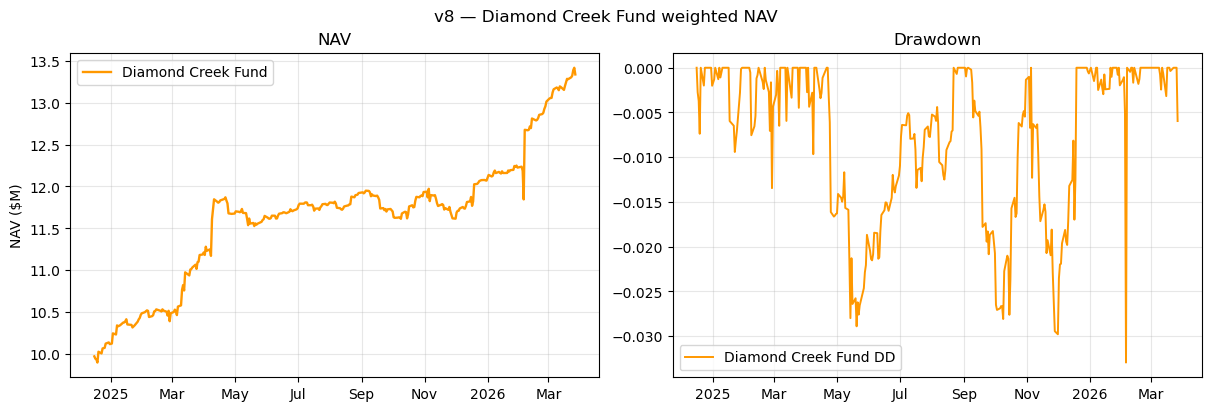

In [130]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ref = max(LEVERAGE_RUNS)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
fig.suptitle("v8 — Diamond Creek Fund weighted NAV")

dc_nav = ALL_BT[ref]["nav"]
ax = axes[0]
ax.plot(dc_nav.index, dc_nav / 1e6, label="Diamond Creek Fund", color="#FF9800", lw=1.7)
ax.set_ylabel("NAV ($M)")
ax.set_title("NAV")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
dd_dc = (dc_nav - dc_nav.cummax()) / dc_nav.cummax()
ax.plot(dd_dc.index, dd_dc, label="Diamond Creek Fund DD", color="#FF9800", lw=1.4)
ax.set_title("Drawdown")
ax.legend()
ax.grid(True, alpha=0.3)

for ax in axes.flat:
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
plt.show()


## Shares Available Audit (Historical Runs)

Uses `data/runs/*/etf_screened_today.csv` to track short availability over time. The first chart shows cross-sectional availability stats by run date; the second heatmap shows per-ticker availability for tickers in the current screener universe.


Runs root used: C:\Users\werdn\Documents\Investing\ls-algo\data\runs
Historical runs loaded: 18 files
Date range: 2025-12-28 -> 2026-03-25
Tickers in audit universe: 383


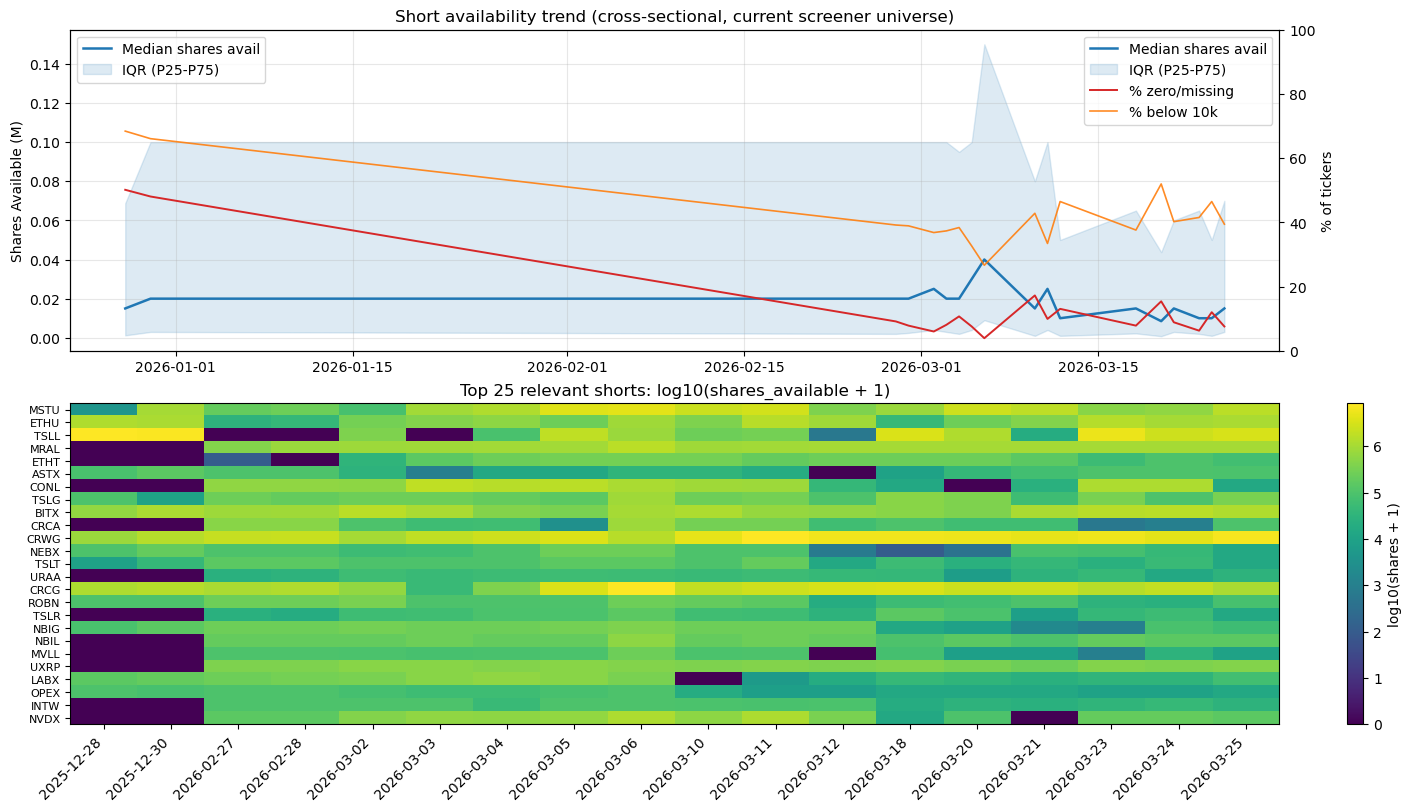

In [131]:
# Resolve runs path robustly (supports data/runs and ../data/runs)
runs_candidates = [
    Path("../data/runs"),
    Path("data/runs"),
    Path.cwd() / "../data/runs",
    Path.cwd() / "data/runs",
    Path.cwd().parent / "data/runs",
]
runs_root = None
for cand in runs_candidates:
    c = cand.resolve()
    if c.exists():
        runs_root = c
        break
if runs_root is None:
    runs_root = Path("../data/runs")

run_files = sorted(runs_root.glob("*/etf_screened_today.csv"))

records = []
for rf in run_files:
    dt = pd.to_datetime(rf.parent.name, errors="coerce")
    if pd.isna(dt):
        continue
    try:
        d = pd.read_csv(rf)
    except Exception:
        continue
    if "ETF" not in d.columns:
        continue

    d["ETF"] = d["ETF"].astype(str).str.upper()
    if "shares_available" in d.columns:
        d["shares_available"] = pd.to_numeric(d["shares_available"], errors="coerce")
    else:
        d["shares_available"] = np.nan

    for r in d[["ETF", "shares_available"]].itertuples(index=False):
        records.append({"date": dt, "etf": r.ETF, "shares_available": r.shares_available})

hist = pd.DataFrame(records)
if hist.empty:
    print(f"No historical runs data found at: {runs_root}")
else:
    hist["date"] = pd.to_datetime(hist["date"])
    hist = hist.sort_values(["date", "etf"]).drop_duplicates(["date", "etf"], keep="last")

    # Resolve current screener path robustly.
    screen_candidates = [
        Path("../data/etf_screened_today.csv"),
        Path("data/etf_screened_today.csv"),
        Path.cwd() / "../data/etf_screened_today.csv",
        Path.cwd() / "data/etf_screened_today.csv",
        Path.cwd().parent / "data/etf_screened_today.csv",
    ]
    current_screen_path = None
    for cand in screen_candidates:
        c = cand.resolve()
        if c.exists():
            current_screen_path = c
            break

    if current_screen_path is not None:
        current_screen = pd.read_csv(current_screen_path)
        if "ETF" in current_screen.columns:
            ref_tickers = sorted(current_screen["ETF"].astype(str).str.upper().unique())
        else:
            ref_tickers = sorted(hist["etf"].unique())
    else:
        ref_tickers = sorted(hist["etf"].unique())

    h = hist[hist["etf"].isin(ref_tickers)].copy()
    piv = h.pivot(index="date", columns="etf", values="shares_available").sort_index()

    if piv.empty:
        print("Shares-availability history is empty after ETF universe filtering.")
    else:
        print(f"Runs root used: {runs_root}")
        print(f"Historical runs loaded: {len(run_files)} files")
        print(f"Date range: {piv.index.min().date()} -> {piv.index.max().date()}")
        print(f"Tickers in audit universe: {len(ref_tickers)}")

        # Interpretable cross-sectional diagnostics.
        p25 = piv.quantile(0.25, axis=1)
        p50 = piv.quantile(0.50, axis=1)
        p75 = piv.quantile(0.75, axis=1)
        pct_zero_missing = ((piv.fillna(0) <= 0).sum(axis=1) / piv.shape[1])
        pct_low_10k = ((piv.fillna(0) < 10_000).sum(axis=1) / piv.shape[1])

        fig, axes = plt.subplots(2, 1, figsize=(14, 8), layout="constrained")

        ax = axes[0]
        ax.plot(p50.index, p50 / 1e6, label="Median shares avail", lw=1.8, color="tab:blue")
        ax.fill_between(p50.index, p25 / 1e6, p75 / 1e6, color="tab:blue", alpha=0.15, label="IQR (P25-P75)")
        ax.set_ylabel("Shares Available (M)")
        ax.set_title("Short availability trend (cross-sectional, current screener universe)")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper left")

        axr = ax.twinx()
        axr.plot(pct_zero_missing.index, 100 * pct_zero_missing, color="tab:red", lw=1.4, label="% zero/missing")
        axr.plot(pct_low_10k.index, 100 * pct_low_10k, color="tab:orange", lw=1.2, alpha=0.9, label="% below 10k")
        axr.set_ylabel("% of tickers")
        axr.set_ylim(0, 100)
        l1, n1 = ax.get_legend_handles_labels()
        l2, n2 = axr.get_legend_handles_labels()
        axr.legend(l1 + l2, n1 + n2, loc="upper right")

        # Heatmap for only relevant names (top weighted if available).
        if "_w_csv" in globals() and {"etf", "weight"}.issubset(_w_csv.columns):
            heat_names = _w_csv.sort_values("weight", ascending=False)["etf"].astype(str).str.upper().head(25).tolist()
        else:
            heat_names = piv.median(axis=0).sort_values(ascending=False).head(25).index.tolist()

        heat_piv = piv.reindex(columns=[x for x in heat_names if x in piv.columns])
        heat = np.log10(heat_piv.fillna(0).T + 1.0)

        ax = axes[1]
        im = ax.imshow(heat.values, aspect="auto", interpolation="nearest", cmap="viridis")
        ax.set_title("Top 25 relevant shorts: log10(shares_available + 1)")
        ax.set_yticks(np.arange(len(heat.index)))
        ax.set_yticklabels(heat.index, fontsize=8)

        n_dates = len(heat_piv.index)
        step = max(1, n_dates // 12)
        xloc = np.arange(0, n_dates, step)
        ax.set_xticks(xloc)
        ax.set_xticklabels([heat_piv.index[i].strftime("%Y-%m-%d") for i in xloc], rotation=45, ha="right")

        cbar = fig.colorbar(im, ax=ax, pad=0.01)
        cbar.set_label("log10(shares + 1)")
        plt.show()


## NAV Jump Attribution (Diamond Creek Fund)

Ranks the largest absolute daily NAV moves and estimates top pair-level contributors on those days using lagged pair gross and pair spread returns.


In [132]:
ref = max(LEVERAGE_RUNS)

beta_map = {e: abs(float(b)) for e, u, b in UNIVERSE}

def _build_pair_contrib_usd(pair_gross_df: pd.DataFrame) -> pd.DataFrame:
    if pair_gross_df is None or pair_gross_df.empty:
        return pd.DataFrame()

    idx = pair_gross_df.index
    contrib = pd.DataFrame(index=idx)

    for col in pair_gross_df.columns:
        if "/" not in col:
            continue
        und, etf = col.split("/", 1)
        if und not in PRICES or etf not in PRICES:
            continue

        pu = PRICES[und].reindex(idx).ffill()
        pe = PRICES[etf].reindex(idx).ffill()
        if pu.isna().all() or pe.isna().all():
            continue

        ru = pu.pct_change().fillna(0.0)
        re = pe.pct_change().fillna(0.0)

        babs = max(1e-9, beta_map.get(etf, 2.0))
        hr = 1.0 / babs
        long_frac = 1.0 / (1.0 + hr)
        short_frac = hr / (1.0 + hr)

        pair_ret = long_frac * ru - short_frac * re
        lag_gross = pair_gross_df[col].shift(1).fillna(0.0)
        contrib[col] = lag_gross * pair_ret

    return contrib


def _print_jump_attribution(label: str, bt: pd.DataFrame, pair_contrib: pd.DataFrame, top_n_days: int = 8, top_n_pairs: int = 5):
    nav = bt["nav"].astype(float)
    nav_ret = nav.pct_change().dropna()
    nav_pnl = nav.diff().fillna(0.0)

    top_days = nav_ret.abs().sort_values(ascending=False).head(top_n_days)

    print(f"\n{'='*78}")
    print(f"{label} — Top {top_n_days} absolute daily NAV moves")
    print(f"{'='*78}")
    for d in top_days.index:
        print(f"{d.date()}  NAV ret={nav_ret.loc[d]:+6.2%}  NAV pnl=${nav_pnl.loc[d]:+,.0f}")

    print(f"\n{label} — Pair attribution on jump days (approx, lag gross × spread return)")
    print(f"{'-'*78}")
    for d in top_days.index:
        if d not in pair_contrib.index:
            continue
        c = pair_contrib.loc[d].dropna()
        if c.empty:
            continue
        top_pairs = c.reindex(c.abs().sort_values(ascending=False).head(top_n_pairs).index)

        print(f"\n{d.date()}  NAV ret={nav_ret.loc[d]:+6.2%}  NAV pnl=${nav_pnl.loc[d]:+,.0f}")
        for pair, v in top_pairs.items():
            print(f"  {pair:>16s}  contrib=${v:+,.0f}")


dc_bt = ALL_BT[ref]
dc_contrib = _build_pair_contrib_usd(ALL_PAIR_GROSS[ref])

_print_jump_attribution("Diamond Creek Fund", dc_bt, dc_contrib)



Diamond Creek Fund — Top 8 absolute daily NAV moves
2026-02-06  NAV ret=+7.01%  NAV pnl=$+830,594
2025-04-09  NAV ret=+3.92%  NAV pnl=$+437,422
2026-02-05  NAV ret=-2.80%  NAV pnl=$-341,784
2025-03-14  NAV ret=+2.01%  NAV pnl=$+216,314
2025-03-11  NAV ret=+1.76%  NAV pnl=$+186,466
2025-12-19  NAV ret=+1.72%  NAV pnl=$+203,268
2024-12-20  NAV ret=+1.30%  NAV pnl=$+128,743
2025-11-06  NAV ret=-1.23%  NAV pnl=$-147,296

Diamond Creek Fund — Pair attribution on jump days (approx, lag gross × spread return)
------------------------------------------------------------------------------

2026-02-06  NAV ret=+7.01%  NAV pnl=$+830,594
         OPEN/OPEX  contrib=$+4,124
         BBAI/BAIG  contrib=$-3,235
         ETHA/ETHT  contrib=$+2,482
         NVDA/NVDG  contrib=$+2,157
         CRCL/CCUP  contrib=$+1,575

2025-04-09  NAV ret=+3.92%  NAV pnl=$+437,422
         SMCI/SMCL  contrib=$+6,607
          ARM/ARMU  contrib=$-6,301
         MSTR/MSTU  contrib=$+5,579
          URA/URAA  contrib=$-

In [133]:
# ---- Joel White Bay: Monthly P&L attribution (trading vs carry vs borrow) ----
ref = max(LEVERAGE_RUNS)


def _build_attribution(bt: pd.DataFrame, label: str, freq: str = "ME") -> pd.DataFrame:
    d = bt.copy().sort_index()

    # Flow components from cumulative series.
    d["long_trading_pnl"] = d["cum_long_pnl"].diff().fillna(d["cum_long_pnl"])
    d["short_trading_pnl"] = d["cum_short_pnl"].diff().fillna(d["cum_short_pnl"])
    d["net_trading_pnl"] = d["long_trading_pnl"] + d["short_trading_pnl"]

    d["interest_income"] = d["cum_margin_credit"].diff().fillna(d["cum_margin_credit"])
    d["margin_interest_paid"] = d["cum_margin_debit"].diff().fillna(d["cum_margin_debit"])
    d["net_interest_carry"] = d["interest_income"] - d["margin_interest_paid"]

    d["borrow_fees_paid"] = d["cum_borrow"].diff().fillna(d["cum_borrow"])
    d["txn_costs_paid"] = d["cum_costs"].diff().fillna(d["cum_costs"])

    d["net_pnl"] = d["nav"].diff().fillna(d["nav"] - d["nav"].iloc[0])

    # Robust gross leverage derivation across engine schema versions.
    if "actual_leverage" in d.columns:
        d["gross_lev"] = pd.to_numeric(d["actual_leverage"], errors="coerce")
    elif "gross_notional" in d.columns:
        d["gross_lev"] = (pd.to_numeric(d["gross_notional"], errors="coerce").abs() / d["nav"].replace(0, np.nan))
    elif {"long_notional", "short_notional"}.issubset(d.columns):
        d["gross_lev"] = (
            (pd.to_numeric(d["long_notional"], errors="coerce").abs() + pd.to_numeric(d["short_notional"], errors="coerce").abs())
            / d["nav"].replace(0, np.nan)
        )
    else:
        d["gross_lev"] = np.nan
    d["gross_lev"] = d["gross_lev"].replace([np.inf, -np.inf], np.nan)

    # Expected bridge from components; residual helps QA.
    d["explained_pnl"] = d["net_trading_pnl"] + d["net_interest_carry"] - d["borrow_fees_paid"] - d["txn_costs_paid"]
    d["residual_pnl"] = d["net_pnl"] - d["explained_pnl"]

    sum_cols = [
        "long_trading_pnl",
        "short_trading_pnl",
        "net_trading_pnl",
        "interest_income",
        "margin_interest_paid",
        "net_interest_carry",
        "borrow_fees_paid",
        "txn_costs_paid",
        "net_pnl",
        "explained_pnl",
        "residual_pnl",
    ]
    out = d[sum_cols].resample(freq).sum()
    out["avg_gross_lev"] = d["gross_lev"].resample(freq).mean()

    if "fed_funds_rate" in d.columns:
        rate = pd.to_numeric(d["fed_funds_rate"], errors="coerce")
        out["benchmark_rate_avg"] = rate.resample(freq).mean()
        out["benchmark_rate_eom"] = rate.resample(freq).last()
    else:
        out["benchmark_rate_avg"] = np.nan
        out["benchmark_rate_eom"] = np.nan

    # Contribution views.
    out["trading_pct_of_net"] = np.where(out["net_pnl"] != 0, out["net_trading_pnl"] / out["net_pnl"], np.nan)
    out["carry_pct_of_net"] = np.where(out["net_pnl"] != 0, out["net_interest_carry"] / out["net_pnl"], np.nan)
    out["borrow_pct_of_net"] = np.where(out["net_pnl"] != 0, -out["borrow_fees_paid"] / out["net_pnl"], np.nan)

    abs_driver = out["net_trading_pnl"].abs() + out["net_interest_carry"].abs() + out["borrow_fees_paid"].abs() + out["txn_costs_paid"].abs()
    out["trading_abs_share"] = np.where(abs_driver > 0, out["net_trading_pnl"].abs() / abs_driver, np.nan)
    out["carry_abs_share"] = np.where(abs_driver > 0, out["net_interest_carry"].abs() / abs_driver, np.nan)
    out["borrow_abs_share"] = np.where(abs_driver > 0, out["borrow_fees_paid"].abs() / abs_driver, np.nan)
    out["txn_abs_share"] = np.where(abs_driver > 0, out["txn_costs_paid"].abs() / abs_driver, np.nan)

    out.insert(0, "portfolio", label)
    out.insert(1, "month", out.index.strftime("%Y-%m"))
    return out.reset_index(drop=True)


monthly_dc = _build_attribution(ALL_BT[ref], "Diamond Creek Fund")
monthly_attr = pd.concat([monthly_dc], ignore_index=True)

print("=" * 108)
print("Monthly P&L Attribution — Trading vs Interest Carry vs Borrow")
print("=" * 108)
print(
    "Columns: net_trading_pnl, net_interest_carry (interest_income - margin_interest_paid), "
    "borrow_fees_paid, txn_costs_paid, net_pnl, avg_gross_lev, benchmark_rate_avg/eom"
)

for name in ["Diamond Creek Fund"]:
    x = monthly_attr[monthly_attr["portfolio"] == name].copy()
    print(f"\n{name} — monthly attribution")
    display(
        x[[
            "month",
            "benchmark_rate_avg",
            "benchmark_rate_eom",
            "avg_gross_lev",
            "long_trading_pnl",
            "short_trading_pnl",
            "net_trading_pnl",
            "interest_income",
            "margin_interest_paid",
            "net_interest_carry",
            "borrow_fees_paid",
            "txn_costs_paid",
            "net_pnl",
            "trading_pct_of_net",
            "carry_pct_of_net",
            "borrow_pct_of_net",
            "residual_pnl",
        ]]
    )

# Compact cumulative summary for fast readout.
summary = (
    monthly_attr.groupby("portfolio", dropna=False)[[
        "net_trading_pnl",
        "net_interest_carry",
        "borrow_fees_paid",
        "txn_costs_paid",
        "net_pnl",
    ]]
    .sum()
    .reset_index()
)
summary["trading_pct_of_net"] = np.where(summary["net_pnl"] != 0, summary["net_trading_pnl"] / summary["net_pnl"], np.nan)
summary["carry_pct_of_net"] = np.where(summary["net_pnl"] != 0, summary["net_interest_carry"] / summary["net_pnl"], np.nan)
summary["borrow_pct_of_net"] = np.where(summary["net_pnl"] != 0, -summary["borrow_fees_paid"] / summary["net_pnl"], np.nan)

print("\nCumulative attribution summary")
display(summary)

daily_attr_dc = ALL_BT[ref].copy()


Monthly P&L Attribution — Trading vs Interest Carry vs Borrow
Columns: net_trading_pnl, net_interest_carry (interest_income - margin_interest_paid), borrow_fees_paid, txn_costs_paid, net_pnl, avg_gross_lev, benchmark_rate_avg/eom

Diamond Creek Fund — monthly attribution


,month,benchmark_rate_avg,benchmark_rate_eom,avg_gross_lev,long_trading_pnl,short_trading_pnl,net_trading_pnl,interest_income,margin_interest_paid,net_interest_carry,borrow_fees_paid,txn_costs_paid,net_pnl,trading_pct_of_net,carry_pct_of_net,borrow_pct_of_net,residual_pnl
0,2024-12,0.043982,0.0433,4.358788,-4.164094e+06,4.378765e+06,2.146712e+05,21271.127803,39279.524659,-18008.396855,46940.594759,30126.906631,145975.192119,1.470600,-0.123366,-0.321566,2.637994e+04
1,2025-01,0.043300,0.0433,4.408230,1.599405e+06,-1.074152e+06,5.252534e+05,45114.331932,83528.455408,-38414.123477,108169.028500,10591.559845,368078.711567,1.427014,-0.104364,-0.293875,3.412424e-09
2,2025-02,0.043300,0.0433,4.420132,-4.544884e+06,4.697992e+06,1.531084e+05,42629.435271,81205.462109,-38576.026838,103892.982198,9593.038130,1046.393830,146.320092,-36.865686,-99.286692,-9.211362e-09
3,2025-03,0.043300,0.0433,4.515789,-2.267419e+06,3.157608e+06,8.901894e+05,50588.051737,96782.355917,-46194.304180,132678.759904,10776.440221,700539.894550,1.270719,-0.065941,-0.189395,-7.639755e-09
4,2025-04,0.043300,0.0433,4.630144,3.790936e+06,-3.071020e+06,7.199159e+05,57300.606614,110640.584156,-53339.977543,161717.735880,17321.628545,487536.603581,1.476640,-0.109407,-0.331704,-1.149601e-09
5,2025-05,0.043300,0.0433,4.703931,6.170179e+06,-5.965580e+06,2.045989e+05,59126.317005,113409.944078,-54283.627073,162190.406098,15873.244477,-27748.347002,-7.373374,1.956283,5.845047,4.030881e-09
6,2025-06,0.043300,0.0433,4.702707,3.453616e+06,-3.161481e+06,2.921354e+05,56057.209214,107597.371633,-51540.162419,153555.472681,8464.107915,78575.646826,3.717887,-0.655930,-1.954237,1.513399e-09
7,2025-07,0.043300,0.0433,4.680684,2.744944e+06,-2.431510e+06,3.134342e+05,61615.145854,119885.052149,-58269.906295,176391.455893,12044.257370,66728.622266,4.697148,-0.873237,-2.643415,1.135049e-09
8,2025-08,0.043300,0.0433,4.736142,-4.493359e+05,8.142022e+05,3.648663e+05,58883.327575,115710.102808,-56826.775234,165881.653582,14154.055041,128003.768823,2.850434,-0.443946,-1.295912,2.764864e-10
9,2025-09,0.042262,0.0409,4.836560,5.546520e+06,-5.499226e+06,4.729391e+04,60062.561341,118181.248795,-58118.687455,175732.095588,18303.966434,-204860.841772,-0.230859,0.283698,0.857812,-1.260196e-08



Cumulative attribution summary


,portfolio,net_trading_pnl,net_interest_carry,borrow_fees_paid,txn_costs_paid,net_pnl,trading_pct_of_net,carry_pct_of_net,borrow_pct_of_net
0,Diamond Creek Fund,6.939029e+06,-816417.823703,2.515984e+06,270247.664674,3.362759e+06,2.063493,-0.242782,-0.74819


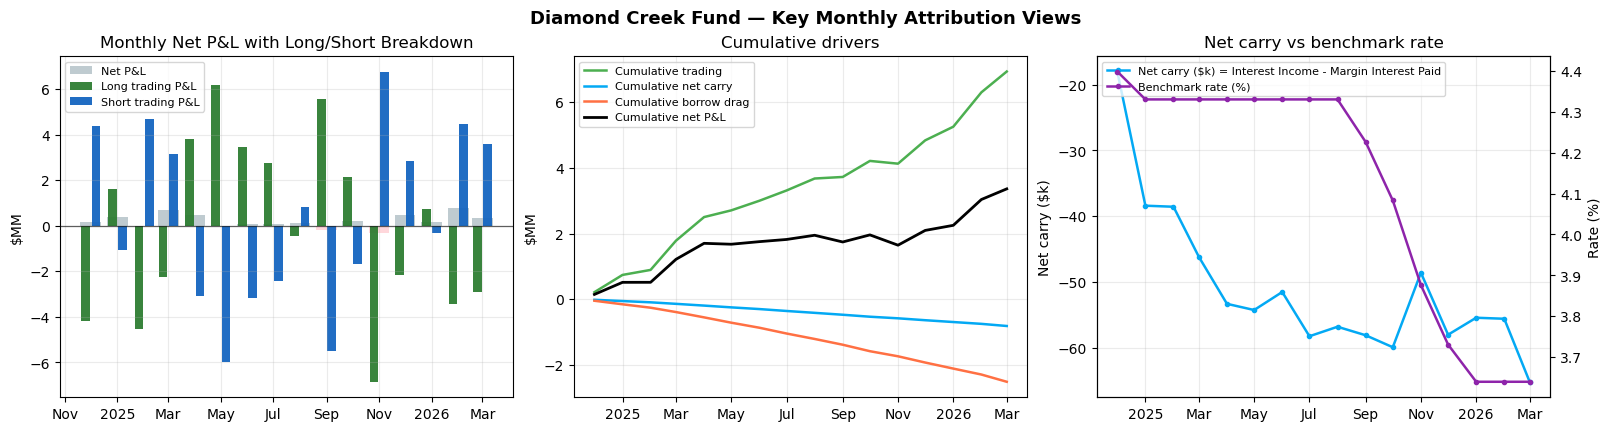

In [134]:
# ---- Joel White Bay: simplified visual attribution trends (monthly) ----
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

if "monthly_attr" not in globals() or monthly_attr.empty:
    raise RuntimeError("Run the monthly attribution cell first.")

m_dc = monthly_attr[monthly_attr["portfolio"] == "Diamond Creek Fund"].copy()
if m_dc.empty:
    raise RuntimeError("Missing Diamond Creek Fund attribution rows.")

m_dc["month_dt"] = pd.to_datetime(m_dc["month"] + "-01")
m_dc.sort_values("month_dt", inplace=True)

x = m_dc["month_dt"]
m_dc["borrow_drag"] = -m_dc["borrow_fees_paid"]

# Benchmark rate is flat when FRED download fails and fallback schedule is sparse.
rate = pd.to_numeric(m_dc.get("benchmark_rate_avg"), errors="coerce")
rate_pct = np.where(rate.abs().max() <= 1.0, rate * 100.0, rate)
if pd.Series(rate_pct).nunique(dropna=True) <= 2:
    print("Benchmark rate is nearly flat in this run (likely fallback rate series after FRED fetch failure).")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), layout="constrained")
fig.suptitle("Diamond Creek Fund — Key Monthly Attribution Views", fontsize=13, fontweight="bold")

# 1) Monthly net P&L with explicit long vs short trading breakdown.
ax = axes[0]
bar_wide = pd.Timedelta(days=24)
bar_narrow = pd.Timedelta(days=10)

# Wide background bar: total monthly net P&L.
net_colors = np.where(m_dc["net_pnl"] >= 0, "#B0BEC5", "#FFCDD2")
ax.bar(x, m_dc["net_pnl"] / 1e6, width=bar_wide, color=net_colors, alpha=0.8, label="Net P&L")

# Narrow bars: long/short trading legs (clear and side-by-side).
x_long = x - pd.to_timedelta(6, unit="D")
x_short = x + pd.to_timedelta(6, unit="D")
ax.bar(x_long, m_dc["long_trading_pnl"] / 1e6, width=bar_narrow, color="#2E7D32", alpha=0.95, label="Long trading P&L")
ax.bar(x_short, m_dc["short_trading_pnl"] / 1e6, width=bar_narrow, color="#1565C0", alpha=0.95, label="Short trading P&L")

ax.axhline(0, color="black", lw=0.9, alpha=0.6)
ax.set_title("Monthly Net P&L with Long/Short Breakdown")
ax.set_ylabel("$MM")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)

# 2) Keep this one as-is (most useful): cumulative drivers.
ax = axes[1]
ax.plot(x, m_dc["net_trading_pnl"].cumsum() / 1e6, label="Cumulative trading", color="#4CAF50", lw=1.8)
ax.plot(x, m_dc["net_interest_carry"].cumsum() / 1e6, label="Cumulative net carry", color="#03A9F4", lw=1.8)
ax.plot(x, m_dc["borrow_drag"].cumsum() / 1e6, label="Cumulative borrow drag", color="#FF7043", lw=1.8)
ax.plot(x, m_dc["net_pnl"].cumsum() / 1e6, label="Cumulative net P&L", color="black", lw=2.0)
ax.set_title("Cumulative drivers")
ax.set_ylabel("$MM")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)

# 3) Very simple carry-rate relationship.
ax = axes[2]
ax.plot(x, m_dc["net_interest_carry"] / 1e3, color="#03A9F4", lw=1.8, marker="o", ms=3, label="Net carry ($k) = Interest Income - Margin Interest Paid")
ax2 = ax.twinx()
ax2.plot(x, rate_pct, color="#8E24AA", lw=1.8, marker="o", ms=3, label="Benchmark rate (%)")
ax.set_title("Net carry vs benchmark rate")
ax.set_ylabel("Net carry ($k)")
ax2.set_ylabel("Rate (%)")
ax.grid(True, alpha=0.25)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="upper left")

for _ax in axes:
    _ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(_ax.xaxis.get_major_locator()))

plt.show()
